# Lesson 184 · GelGT

One skill: separate legal context, retained context and temporal attention. PROVIDED cells expose the implementation; TODO cells are yours; CHECK invokes your actual functions; EXIT needs a written defense. TierB: complete real F1 database/task packet; TierC: controlled mechanism counterexamples. This is an executable source audit, not a completed full GelGT reproduction.

In [ ]:
# @colab-bootstrap
from pathlib import Path
import ast,base64,hashlib,io,json,math,random,typing,importlib.util,zipfile
from collections import defaultdict,deque
from types import SimpleNamespace
import numpy as np
import pandas as pd
import pyarrow,duckdb,torch
print("Dependencies loaded; full training NOT_RUN; cloud $0")

## One skill: separate access, selection and attention

A larger neighborhood helps only when it supplies useful information that was available for the query. By the end, you should be able to trace one GelGT prediction through those three decisions and reject a reproduction that confuses them.

This serves our mission: make relational-model gains defensible through visible computation and a valid experiment. [Lesson 145](https://avistian.github.io/relational/lessons/0145-relational-graph-transformer.html) introduced the relational Transformer family; use the [course map](https://avistian.github.io/relational/reference/curriculum.html) if that lesson's title has changed. [Lesson 183](https://avistian.github.io/relational/lessons/0183-graph-transformer-pretraining.html)'s proposed pretraining experiment asks a different question: GelGT is trained directly on its downstream task. You do not need an unfinished previous lesson to follow this one.

**Recall first.** A primary key identifies a row. A foreign key connects it to a row in another table. A query cutoff is the time at which a prediction must be possible. An attention weight tells us how much an already-admitted value contributes; it does not grant access to that value.

From memory: define complete query identity, validation-only selection and temporal availability.

> **Scope check.** Selected GelGT reproduction **INCOMPLETE_SOURCE_TEMPORAL_GATE**. Fresh training **NOT_RUN**. Local source/mechanism audit and all **8,712 labels PASS**. Cloud/API **$0**. Learner **PENDING_WRITTEN_DEFENSE**.

## Why reach alone is insufficient

**In plain terms.** Imagine predicting a driver's next finishing position. One nearby race may connect the driver to a constructor, then to other drivers. A message-passing network transports information through these edges in successive layers. Compressing many paths into fixed-size vectors can lose distinctions. Attention can connect sampled tokens directly, but cannot use a useful row that the sampler discarded.

A **token** is a vector representing a sampled row for this query. A **hop** is one graph edge. GelGT addresses three bottlenecks: retain the local relational structure, choose useful distant nodes, then learn which time differences matter. It does not prove that every long-range problem disappears. Read the [primary paper §§3.1–3.2](https://arxiv.org/html/2605.15575v2#S3).

## Model architecture: database to one number

<figure class="route-figure" tabindex="0">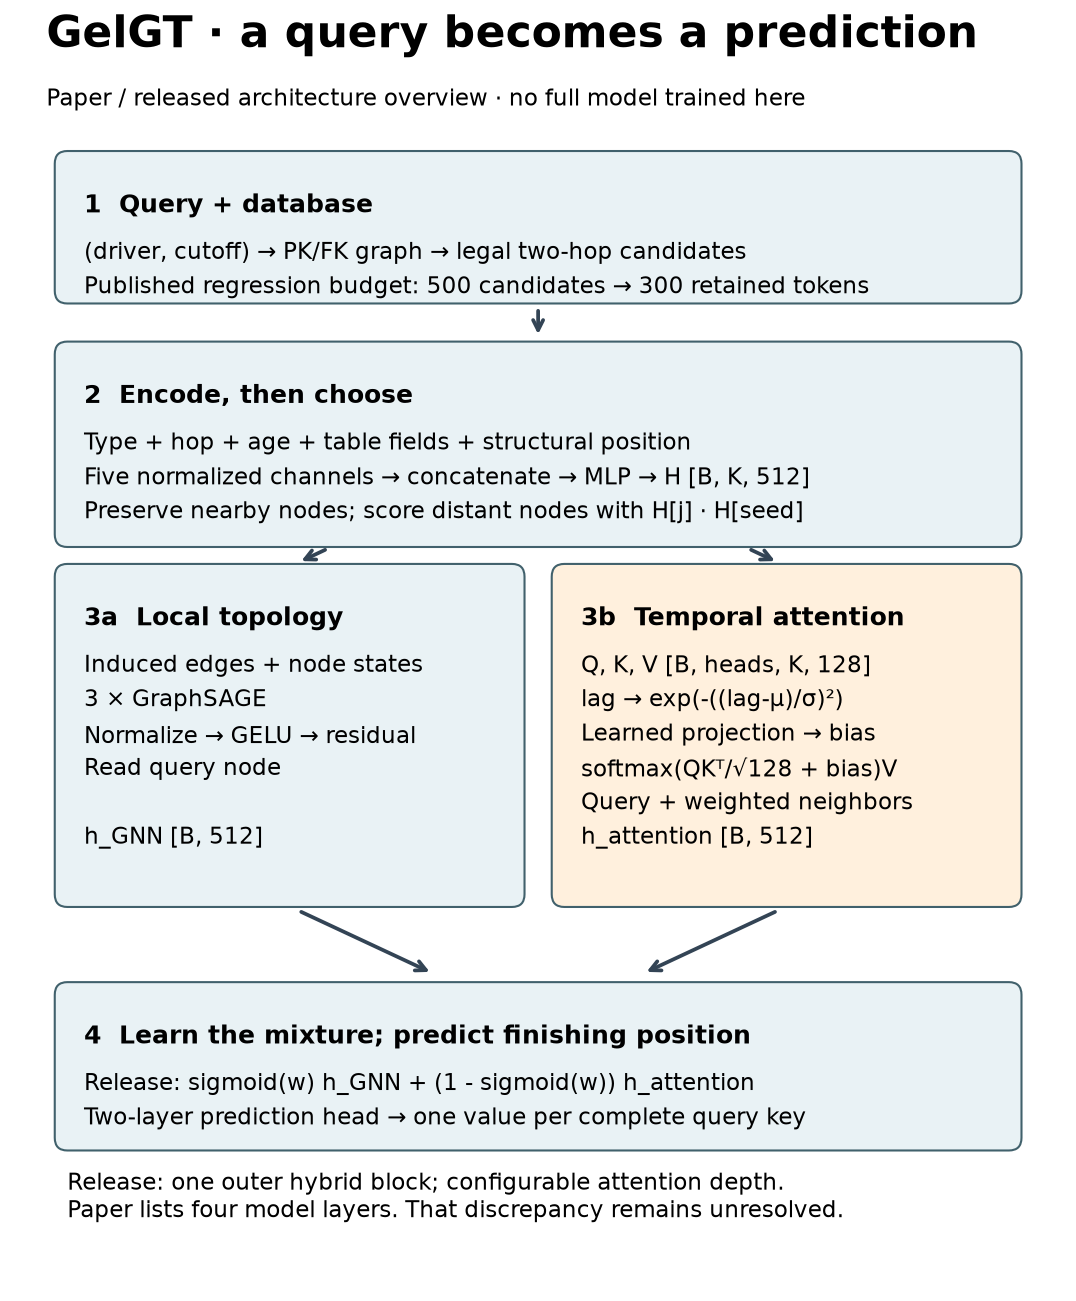<figcaption>Paper/release GelGT architecture. The released outer hybrid loop has one block; published depth remains unresolved. No full model fit ran.</figcaption></figure>

**Start with a query.** For regression, the published sampling budgets are 500 candidates and 300 retained tokens. `B` denotes a batch of queries, `K` the token count, and 512 the hidden width. Each token receives representations of its table type, hop distance, relative time, table fields and structural position. Normalization puts each channel on a controlled scale; concatenation joins channels side by side; a small multilayer perceptron mixes them into one vector.

**Choose context after encoding.** The seed is the query's own row. Nearby nodes are protected; more distant candidates are ranked using their dot product with the seed vector. A dot product multiplies matching coordinates and sums them. It is a learned compatibility score, not a guarantee of relevance.

**Compute two summaries.** Three GraphSAGE layers aggregate along retained edges, keeping local topology visible. In parallel, multi-head attention compares retained tokens and adds a time-dependent bias to each comparison. A head is a separate learned comparison subspace. The attention branch combines the query representation with a weighted neighbor summary.

**Fuse and predict.** The release learns a sigmoid gate: `g = 1/(1+exp(-w))`, between zero and one. It mixes `g × GNN + (1−g) × attention`; a two-layer head predicts one finishing-position value. The full released model and trainer appear in the notebook appendix. The paper/source depth discrepancy remains explicit in the [protocol ledger](https://avistian.github.io/relational/labs/l184-reproduction.md).

## Mechanism 1: preserve a legal relational route

**Worked example.** Driver 0 connects to races on days 5 and 15. At cutoff day 10, only day 5 is available under a strict prior-time rule. At day 20, both are available. These are different queries, even though the driver is unchanged.

<figure class="route-figure" tabindex="0">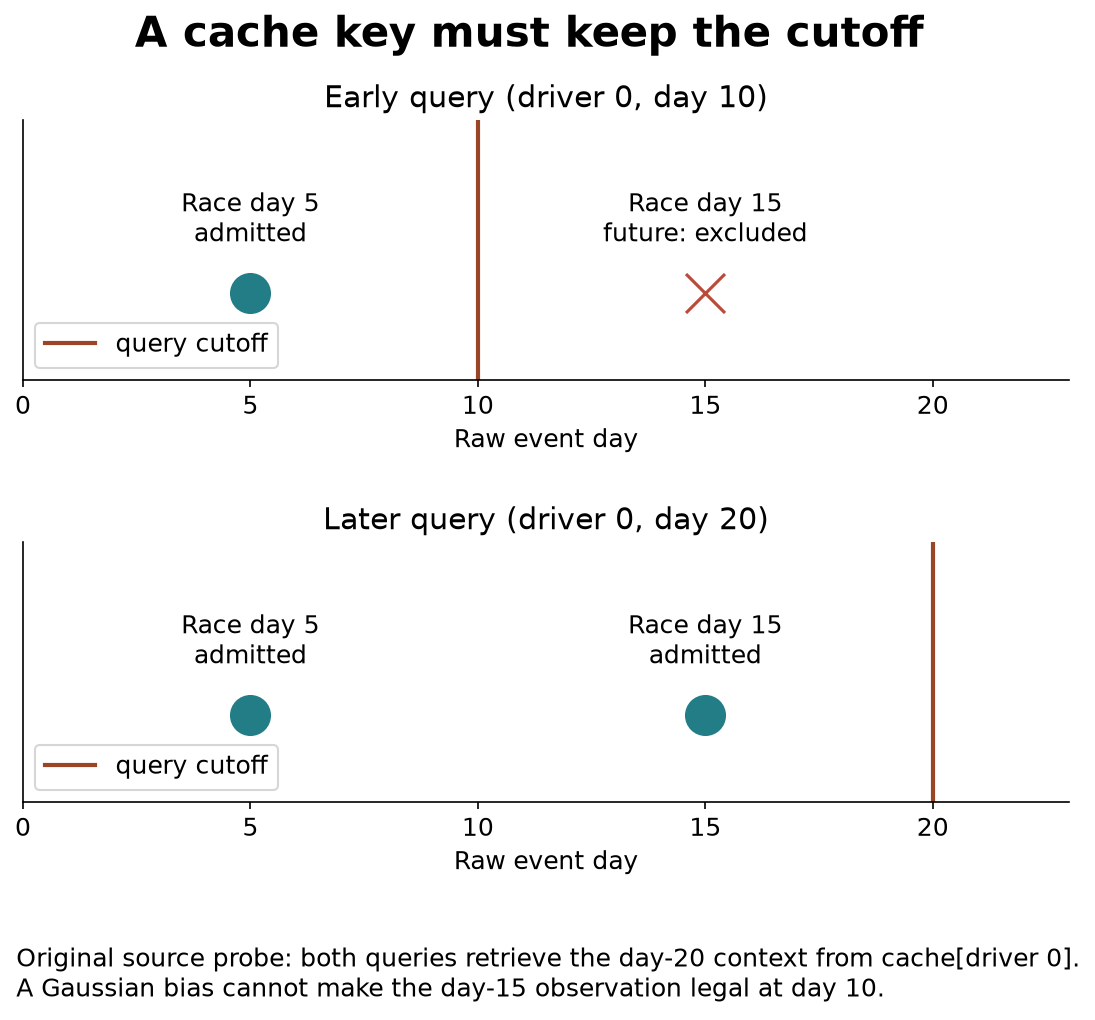<figcaption>Synthetic original-source cache counterexample: raw days5and15, cutoffs10and20. The early query incorrectly reuses the late context.</figcaption></figure>

**Breadth-first sampling** visits all one-hop neighbors before expanding two-hop neighbors. With a finite budget, it favors broad local coverage. The retained **induced graph** includes the original edges whose two endpoints survived. An invalid future node must be rejected before traversal; merely hiding its target is insufficient.

> **Scope check.** The teaching sampler uses sorted ties, strict `< cutoff`, and excludes untimed rows. The release uses `<=` and admits untimed rows. The paper contains both strict and non-strict descriptions. These policies are recorded separately, not silently equated. The course policy still needs ingestion histories before it establishes real deployment availability.

## Mechanism 2: rank distant candidates without losing the seed

**Worked example.** Let the seed embedding be `[1,0]`. One-hop node A has embedding `[0,1]`; distant nodes B and C have `[0.1,0]` and `[2,0]`. Their seed dot products are 0, 0.1 and 2. With room for three tokens, protect seed and A, then retain C. B loses its slot.

| Token | Hop | Score | Three-token outcome |
|---|---:|---:|---|
| Seed | 0 | 1 | Protected |
| A | 1 | 0 | Protected |
| B | 2 | 0.1 | Removed |
| C | 2 | 2 | Retained |

This isolates semantic ranking: candidate graph, embeddings and budget stay fixed; only the distant score determines the last slot. If there are more protected nodes than slots, the course implementation raises an error. The release uses large sentinel scores and top-k; ties require care. After selection, remap edge indices to the new token positions.

**Try before the lab.** Reverse B and C's embeddings. Predict which edge disappears. Then decrease the budget to one: explain why quietly removing the seed would corrupt the prediction readout.

## Mechanism 3: learn a preferred temporal band

**In plain terms.** Useful evidence need not be the newest evidence. A model may prefer a band of lags, such as roughly two days ago. The center says where that band sits; the width says how quickly preference falls away.

For a pair of tokens, `Δt` is their absolute time difference. A Gaussian feature is:

`r(Δt) = exp(−((Δt − μ)/σ)²)`

Here `μ` is the center and `σ` is a positive width. The release uses `abs(raw_sigma)+0.00001`. There is no factor of one-half in this kernel. Several such features are passed through a learned linear projection to obtain one bias per attention head. Projection weights may be negative, so a large Gaussian feature need not increase attention.

**Worked example.** With lags `[0,2,4]`, center 2 and width 2, the squared normalized distances are `[1,0,1]`. Exponentiation gives `[0.368,1,0.368]`. For an illustrative identity projection and equal content scores, softmax converts these biases into weights that sum to one. Softmax exponentiates each score and divides by the sum of the exponentials.

<figure class="route-figure" tabindex="0">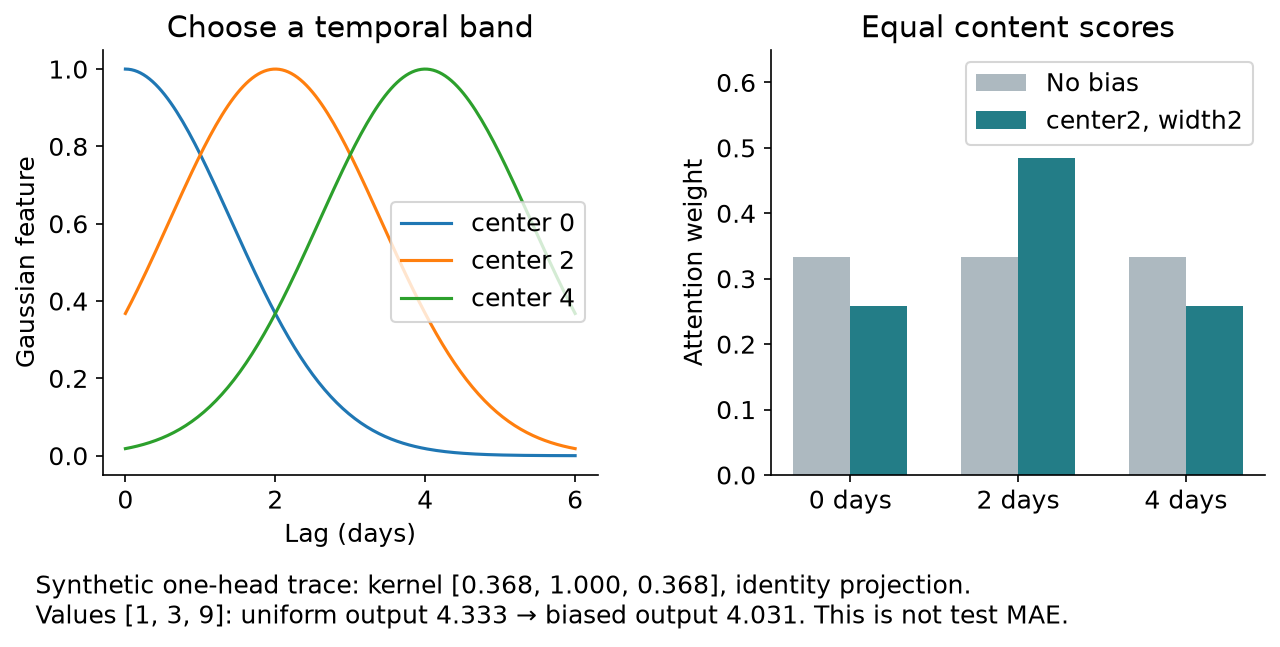<figcaption>Synthetic Gaussian feature and one-head attention trace. Equal content scores and identity projection; not a trained performance result.</figcaption></figure>

**The complete operation.** Learned query and key vectors produce content scores `QKᵀ/√d_head`; `d_head` is the width of one head. Add the temporal bias, apply softmax, and take the weighted sum of the value vectors `V`. This changes contribution, not temporal legality. The source-executed lab checks this entire attention layer against explicit matrix arithmetic and compares input gradients.

Use the TRY cell to change center, width and projection. Keep values/content scores fixed.

**Predict an intervention.** Set projection to zero. The temporal contribution should disappear. Set it to minus one: the preference reverses. This is why a special-case scalar kernel calculation cannot establish an unconditional performance gain or a universal attention-ratio theorem for every trained projection.

## Reproduction: a failed prerequisite is evidence

Predict before reading: can two cutoff contexts survive in a dictionary keyed by driver alone?

**Named target.** GelGT v2 Table 2, `rel-f1/driver-position`: reported test MAE **3.7345 ± 0.1200**. Mean absolute error averages the absolute distance between predictions and labels; lower is better. We have not produced a new model MAE. The [official source](https://github.com/USTC-DataDarknessLab/GelGT/tree/1997b2c2f480ce5d3cbdb48d46f33cc303f5feb4) is pinned, rather than following a moving branch.

**What ran.** All nine cached database tables and all three task splits are authenticated. SQL reconstructs every target from raw race-result rows. Original sampling functions execute on a temporal counterexample. Original attention executes on controlled tensors; independent arithmetic checks outputs and gradients. These checks have different evidence boundaries.

| Split | Complete queries | Entity-only entries | Lost distinct entries |
|---|---:|---:|---:|
| train | 7,453 | 771 | 6,682 |
| val | 499 | 47 | 452 |
| test | 760 | 56 | 704 |

All labels reconstruct with maximum error **0**. Original attention: maximum forward error **4.44×10⁻¹⁶** and input-gradient error **2.15×10⁻¹⁵** in a float64, dropout-zero controlled test. Synthetic source probe: **2 queries → 1 cache entry**, admitting one future node to the early query.

**Why the gate fails.** The release's context dictionary uses `S[table][entity]`, then retrieves that entry for every matching entity in a 10,000-row chunk. Each complete F1 split fits within one chunk. The later query overwrites the earlier entry. The synthetic source execution demonstrates that this can pass a future race to an earlier query. The stored lag is relative to the later cutoff, so it may still look nonnegative.

**What the counts mean.** Cache collisions count lost distinct query entries, not observed future-row occurrences across the complete database. We did not run the full graph materialization, training, or full-population context audit after this blocker. Correct labels do not imply correct features.

**What would permit a future experiment.** Preserve full query keys through sampling and caching; authenticate per-query raw timestamps; settle padding, fitting scope, evaluation dropout, source/paper configuration and seed aggregation; then measure the full cost before dispatch. A repaired release defines a new declared protocol. It cannot be described as an unchanged historical reproduction.

> **Scope check.** The aggregate ceiling is $10 including retries and verification, with a planned stop at $8 and $2 reserve. No paid pilot ran because the scientific gate failed earlier. Full reproduction remains **INCOMPLETE**. Nothing here changes the learner's mastery record or claims deployment.

## Lab: implement, intervene, defend

Download the [student notebook](https://avistian.github.io/relational/labs/0184-gelgt-temporal-attention.ipynb), inspect the [executed solution](https://avistian.github.io/relational/labs/html/0184-gelgt-temporal-attention.html), or use the [quick reference](https://avistian.github.io/relational/reference/gelgt-temporal-attention.html). The portable notebook embeds the data, source and figures. It needs Python, NumPy, pandas, PyArrow, DuckDB and PyTorch; live Colab is **NOT_CHECKED**.

1. Implement strict two-hop temporal sampling; test earlier and equal cutoffs.
2. Implement the Gaussian feature; compare it against the actual release's bias and attention arithmetic.
3. Implement complete-key MAE; reject duplicate, missing and nonfinite predictions.
4. Run the source counterexample and all 8,712 label reconstructions. Change one assumption and explain the boundary it affects.

The synthetic attention output is not a prediction benchmark. The notebook deliberately leaves fresh training gated off. Inspect the [full protocol and exact commands](https://avistian.github.io/relational/labs/l184-reproduction.md) and [machine-readable evidence](https://avistian.github.io/relational/labs/evidence/l184/report.json).

Defend access, selection and weighting in the EXIT response below.

**Bridge forward.** A temporally valid prediction is still not a causal intervention. [Lesson 185](https://avistian.github.io/relational/lessons/0185-causal-relational-data.html) asks whether acting on a prediction changes an outcome. First make the information contract correct; then ask what decision the model supports.

Ask the teaching agent about any unclear step, or paste your written defense for feedback. Preparing this lesson does not count as completing it.


## PROVIDED · Authenticate the complete packet
No network required. Dependencies must already be installed: numpy,pandas,pyarrow,duckdb,torch. Archive hashes establish bytes, not historical usage. Embedded source is unmodified. Extraction permits only relative packet paths.

In [ ]:
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='fe09e3b088a410c5660c29a81a2a869e9494f13d8aec16126d6fce5013d16daa'
P=Path('l184-packet');P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(P)
manifest={'data_provenance': 'Authenticated locally cached RelBench F1 archives, matches earlier source audit; GelGT historical archive identity unestablished', 'archives': {'db.zip': 'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482', 'tasks/driver-position.zip': '775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}, 'files': {'db/circuits.parquet': 'c36c6537b9c5c9985ec438110717e93289085a5bffbcee07d08bbe1771994d8d', 'db/constructor_results.parquet': '35582c2f0634d5503b664babf38264311332e6ca3cb612fb0fe737bfaffdc29e', 'db/constructor_standings.parquet': '739fc21ba301ef2081dbd8e56d643f148b672224a4d223b95d6107ccd735aa6b', 'db/constructors.parquet': 'fc79dd346430186cdca6263e1c532891bf4d4ba7463fd94b398350a9356180c6', 'db/drivers.parquet': 'ba3461b83a1a467a856bde4059519140a5a31952ad24a5e944ea9dd5c5faceae', 'db/qualifying.parquet': '2d5cb7b4ed6cf4076b74ab1cc79f5f35faf31b7f032b51d2a1ac814e1d0c834b', 'db/races.parquet': '88bb260f03c9ec5c7b030969d7284531d5f8e8592d73174686ad01cdfc8f87ea', 'db/results.parquet': 'b8b0e39b27f318a7bd461f21bb0ba9ef44909ed569d287e0c6b2969c6bd2f598', 'db/standings.parquet': 'f3f6a34fee190f077f2fe48026a7e5659e4c91a34f72340cdff3cf407c1f3534', 'task/test.parquet': '28a0a58c955a770234b55f00d7aa9badef20bd22fd3b8478d17f9312c5f452be', 'task/train.parquet': '3d7c53d747f2e865e63e0fd1b34c3cfa9b64dd78af7096ca98beb4aae76c0ee0', 'task/val.parquet': '7d2d147d22e53ef94f6a5122a8559e4c9c72196c4d6399cb370cd95a5b86c0f0', 'task-definition.py': '57ec97831ffa5679f2444f8947692c5096abe1b9d0ed9190d4e9c062a5d69aa2', 'upstream/README.md': 'a411412300c59e2bf452088054f5a6285c079016d1e2e24d97c31877f8c6ef6a', 'upstream/codebook.py': '77bfe9d63a6eb5bf34897ee9b633e11375ffc96fdc9c90de31f5a39e19262ba6', 'upstream/encoders.py': '153c20dcdb6a113fc6eb6f8c8cfb2f738f16fdb2005e6004bb837ff4a40ad155', 'upstream/local_module.py': '43ff0b577ac957dd8224bed5d7ba3d7dc7f75f60274c9268827aa000395a0deb', 'upstream/main_node_ddp.py': '213f007b071a4cc609bf7fb008ff3d038e0ce3350378ca382eb9d4f0aa2dd16e', 'upstream/model.py': 'd16e81f9dd6cb7391d3428b0aec4c5d357780df664b404be2f59f3d6a82ef7a4', 'upstream/requirements.txt': '0dc3acb0bd2a9e8cacd6651818b85cd0f4962fba0e573bc4ce67ea1468ba276e', 'upstream/utils.py': '235d19418421c065e96065121b8f088f7b38d3832fcc80bf83223b8999a5d8fb'}}

## TODO · Preserve access before selection
**Goal:** Return seed-first, sorted, undirected two-hop BFS. Budget includes seed. Admit only finite timestamps strictly below cutoff; exclude untimed nodes. Refuse invalid inputs. Reversing the edge list must not change the answer.

**Why:** a silent access, arithmetic or identity change invalidates model comparisons.

In [ ]:
def temporal_bfs(edges, times, seed, cutoff, budget):
    raise NotImplementedError("Implement temporal_bfs")

### CHECK · Immediate feedback

In [ ]:
assert temporal_bfs([(0,1),(1,2)],[0,5,15],0,10,3)==[0,1]
print('Immediate CHECK passed')

## TODO · Compute temporal features
**Goal:** Accept an array of lags and finite scalar center/positive effective width. Return the Gaussian radial feature array. Reject nonpositive/nonfinite width and nonfinite inputs. Your function is used inside the actual source-bias parity audit.

**Why:** a silent access, arithmetic or identity change invalidates model comparisons.

In [ ]:
def gaussian_features(lags, center, width):
    raise NotImplementedError("Implement gaussian_features")

### CHECK · Immediate feedback

In [ ]:
assert np.allclose(gaussian_features([0,2,4],2,2),[math.exp(-1),1,math.exp(-1)])
print('Immediate CHECK passed')

## TODO · Keep the cutoff in evaluation
**Goal:** Input rows are(entity,cutoff,value). Join truth and predictions on the complete key, ignoring order. Reject duplicate/empty/missing populations or nonfinite values. Return mean absolute error.

**Why:** a silent access, arithmetic or identity change invalidates model comparisons.

In [ ]:
def keyed_mae(truth, predictions):
    raise NotImplementedError("Implement keyed_mae")

### CHECK · Immediate feedback

In [ ]:
assert keyed_mae([(1,2,1.),(1,3,5.)],[(1,3,5.),(1,2,3.)])==1.
print('Immediate CHECK passed')

## PROVIDED · Semantic selection and attention trace
These functions use the same numbers as the lesson. The semantic budget refusal is a course policy; it is not patched into the original release.

In [ ]:
def semantic_refine(embeddings, hops, keep):
    """Course policy: preserve seed + all one-hop nodes, rank distant nodes.

    Reject impossible protected budgets rather than dropping the seed in ties.
    Stable score ties use original index; return indices in original order.
    """
    x=np.asarray(embeddings,float);h=np.asarray(hops)
    if x.ndim!=2 or len(x)!=len(h) or not np.isfinite(x).all() or h[0]!=0:
        raise ValueError('invalid tokens')
    protected=np.flatnonzero(h<=1).tolist()
    if not len(protected)<=keep<=len(x):raise ValueError('protected nodes exceed budget')
    scores=x@x[0]
    candidates=sorted((i for i in range(len(x)) if h[i]==2),key=lambda i:(-scores[i],i))
    selected=protected+candidates[:keep-len(protected)]
    if len(selected)!=keep:raise ValueError('insufficient real candidates')
    return sorted(selected)

In [ ]:
def attention_trace(lags, center=2., width=2., projection=1.):
    """Synthetic single-head example with equal QK logits, values [1,3,9]."""
    bias=projection*gaussian_features(lags,center,width)
    weights=np.exp(bias-bias.max());weights/=weights.sum()
    return {'bias':bias.tolist(),'weights':weights.tolist(),
            'output':float(weights@np.array([1.,3.,9.]))}

## CHECK · Independent scalar arithmetic and adversarial contracts
Three incorrect implementations must fail. One hundred random Gaussian cases are checked with scalar math; one hundred shuffled keyed populations retain the same score.

In [ ]:
def checks(sample, gaussian, score):
    edges=[(0,1),(0,2),(1,3),(2,4),(0,5)]
    times=[0,8,9,7,11,10]
    assert sample(edges,times,0,10,4)==[0,1,2,3], 'BFS must reject equal/future times'
    assert sample(edges,times,0,9,4)==[0,1,3], 'earlier cutoff changes legal context'
    assert sample(edges[::-1],times,0,10,4)==[0,1,2,3], 'stable tie order'
    x=gaussian(np.array([0.,2.,4.]),2.,2.)
    assert np.allclose(x,[math.exp(-1),1,math.exp(-1)]), 'source kernel has no factor 1/2'
    for width in [0,-1,float('nan')]:
        try:gaussian(np.array([0.]),0.,width)
        except ValueError:pass
        else:raise AssertionError('invalid width accepted')
    y=[(1,2,1.),(1,3,5.),(2,3,7.)];p=[(2,3,6.),(1,2,2.),(1,3,5.)]
    assert abs(score(y,p)-2/3)<1e-12, 'join on entity AND cutoff'
    for bad in [p[:-1],p+[p[0]],[(2,3,float('nan'))]+p[1:]]:
        try:score(y,bad)
        except ValueError:pass
        else:raise AssertionError('corrupt predictions accepted')
    return 'PASS'

In [ ]:
def independent184(sample,gaussian,score):
    checks(sample,gaussian,score)
    rng=random.Random(184)
    for i in range(100):
        mu=rng.uniform(-5,5);width=rng.uniform(.1,10);lags=[rng.uniform(0,10) for _ in range(5)]
        assert np.allclose(gaussian(lags,mu,width),[math.exp(-(v-mu)**2/width**2) for v in lags],atol=1e-14)
        truth=[(k%7,k,float(rng.random())) for k in range(25)]
        pred=[(e,t,y+.25) for e,t,y in truth];rng.shuffle(pred)
        assert abs(score(truth,pred)-.25)<1e-12
    # Three distinct incorrect learner implementations must be rejected.
    wrong=[(lambda *a:[0,1,2,3],gaussian,score),(sample,lambda x,m,w:np.ones_like(x),score),(sample,gaussian,lambda y,p:0.)]
    for trio in wrong:
        try:checks(*trio)
        except (AssertionError,ValueError):pass
        else:raise AssertionError('Wrong learner implementation accepted')
    return {'status':'PASS','random_scalar_cases':100,'random_keyed_cases':100,'wrong_learner_functions_rejected':3}

In [ ]:
print(independent184(temporal_bfs,gaussian_features,keyed_mae))
assert semantic_refine([[1,0],[0,1],[.1,0],[2,0]],[0,1,2,2],3)==[0,1,3]

## PROVIDED + CHECK · Execute the original source counterexample
Only the process Pool is replaced by a serial adapter. Original function bodies stay unchanged. The attention module is imported from authenticated bytes. Independent QK/softmax/V arithmetic checks output and input gradients at dropout0. Raw SQL reconstructs every real label. This audit calls your Gaussian implementation; synthetic scoring checks use your complete-key MAE.

In [ ]:
def audit184(packet,manifest,gaussian):
    packet=Path(packet)
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Changed authenticated input: '+name)
    torch.set_num_threads(1)
    src=packet/'upstream'
    # Compile the original sampling functions unchanged. Only the process pool
    # is replaced by an in-process executor, to keep this diagnostic portable.
    tree=ast.parse((src/'utils.py').read_text())
    wanted={'gather_1_and_2_hop_with_seed_time','_process_one_seed','local_nodes_hetero'}
    code=ast.Module(body=[n for n in tree.body if isinstance(n,ast.FunctionDef) and n.name in wanted],type_ignores=[])
    class SerialPool:
        def __init__(self,processes,initializer,initargs):initializer(*initargs)
        def __enter__(self):return self
        def __exit__(self,*args):pass
        def map(self,fn,args):return list(map(fn,args))
    ns=dict(vars(typing));ns.update(np=np,torch=torch,random=random,defaultdict=defaultdict,deque=deque,HeteroData=object,Pool=SerialPool)
    adj={'driver':[{('race',0),('race',1)}], 'race':[{('driver',0)},{('driver',0)}]}
    def init(adj,nodes):ns.update(GLOBAL_ADJ=adj,GLOBAL_ALL_NODES=nodes)
    ns['init_worker_globals']=init;init(adj,[])
    exec(compile(code,'pinned-utils.py','exec'),ns)
    day=86400.;data={'driver':SimpleNamespace(),'race':SimpleNamespace(time=torch.tensor([5*day,15*day]))}
    args=(data,3,'driver',0)
    early=ns['_process_one_seed']((*args,10*day,42))[2]
    late=ns['_process_one_seed']((*args,20*day,42))[2]
    collapsed=ns['local_nodes_hetero'](data,3,('driver',torch.tensor([0,0])),torch.tensor([10*day,20*day]),num_workers=1)
    shared=collapsed['driver'][0][0]
    assert len(early)==2 and len(late)==3 and len(shared)==3
    assert len(collapsed['driver'])==1
    leak=[n[1] for n in shared if n[0]=='race' and data['race'].time[n[1]].item()>10*day]
    assert leak==[1]
    # Execute actual source attention in float64 and compare independent kernels,
    # then reconstruct a full EncoderLayer with explicit matrix multiplication.
    mod=SimpleNamespace(__name__='l184_pinned_local')
    exec(compile((src/'local_module.py').read_text(),'pinned-local_module.py','exec'),mod.__dict__)
    torch.manual_seed(184)
    lm=mod.LocalModule(3,8,n_layers=1,num_heads=2,hidden_dim=8,dropout_rate=0,attention_dropout_rate=0,max_time_days=4).double().eval()
    x=torch.randn(2,3,8,dtype=torch.float64,requires_grad=True);times=torch.tensor([[0.,2.,4.],[0.,1.,3.]],dtype=torch.float64)
    captured={}
    handle=lm.layers[0].register_forward_pre_hook(lambda m,a,kw:captured.update(bias=kw['attn_bias']),with_kwargs=True)
    y=lm(x,neighbor_times=times,pretrain_token=True);handle.remove()
    diff=abs(times.numpy()[:,:,None]-times.numpy()[:,None,:])
    kernels=np.stack([gaussian(diff,float(mu),abs(float(sig))+1e-5) for mu,sig in zip(lm.kernel_mu.detach(),lm.kernel_sigma.detach())],axis=-1)
    expected=kernels@lm.kernel_proj.weight.detach().numpy().T+lm.kernel_proj.bias.detach().numpy()
    kernel_error=float(np.max(abs(expected.transpose(0,3,1,2)-captured['bias'].detach().numpy())))
    assert kernel_error<1e-12
    layer=lm.layers[0];z=lm.att_embeddings_nope(x);norm=layer.self_attention_norm(z)
    q,k,v=[f(norm).view(2,3,2,4).transpose(1,2) for f in (layer.q_proj,layer.k_proj,layer.v_proj)]
    w=torch.softmax(q@k.transpose(-1,-2)/2+captured['bias'],dim=-1)
    a=(w@v).transpose(1,2).reshape(2,3,8)
    z=z+layer.out_proj(a);manual=lm.final_ln(z+layer.ffn(layer.ffn_norm(z)))
    forward_error=float((manual-y).abs().max().detach());assert forward_error<1e-12
    g1=torch.autograd.grad(y.square().sum(),x,retain_graph=True)[0]
    g2=torch.autograd.grad(manual.square().sum(),x)[0]
    grad_error=float((g1-g2).abs().max());assert grad_error<1e-10
    # All released driver-position labels: raw join independent of task code.
    results=pd.read_parquet(packet/'db/results.parquet');drivers=pd.read_parquet(packet/'db/drivers.parquet')
    counts={};collision={};label_error=0.;total=0
    for split in ['train','val','test']:
        truth=pd.read_parquet(packet/'task'/f'{split}.parquet')
        assert not truth.duplicated(['driverId','date']).any()
        timestamps=pd.DataFrame({'cutoff':truth.date.unique()})
        rebuilt=duckdb.sql('''SELECT t.cutoff AS date,d.driverId,avg(r.positionOrder) AS position
         FROM timestamps t JOIN results r ON r.date>t.cutoff AND r.date<=t.cutoff+INTERVAL '60 days'
         JOIN drivers d ON d.driverId=r.driverId
         WHERE d.driverId IN (SELECT driverId FROM results WHERE date>t.cutoff-INTERVAL '1 year')
         GROUP BY t.cutoff,d.driverId''').df()
        joined=truth.merge(rebuilt,on=['driverId','date'],how='outer',suffixes=('_y','_sql'),indicator=True)
        assert (joined['_merge']=='both').all()
        error=float(abs(joined.position_y-joined.position_sql).max());assert error<1e-12
        label_error=max(label_error,error);counts[split]=len(truth);total+=len(truth)
        # Source chunk size is 10000; all three complete populations fit one chunk.
        assert len(truth)<=10000
        collision[split]={'queries':len(truth),'unique_entities':int(truth.driverId.nunique()),
           'overwritten_query_entries':int(len(truth)-truth.driverId.nunique()),
           'rows_sharing_entity':int(truth.duplicated('driverId',keep=False).sum())}
    return {'audit':'PASS','selected_experiment':'INCOMPLETE_SOURCE_TEMPORAL_GATE','fresh_training':'NOT_RUN',
      'paper_target_mae':3.7345,'measured_model_mae':None,'whole_paper':'NOT_RUN','historical_identity':'NOT_ESTABLISHED',
      'labels':total,'counts':counts,'label_max_error':label_error,'cache_collisions':collision,
      'synthetic_source_probe':{'input_queries':2,'output_cache_entries':1,'early_legal_tokens':len(early),'reused_late_tokens':len(shared),'future_nodes_in_early_context':leak},
      'kernel_max_error':kernel_error,'attention_forward_max_error':forward_error,'attention_input_gradient_max_error':grad_error,
      'scope':'Original sampling functions and attention module executed; full model/trainer NOT_RUN. Synthetic leak is a counterexample, not a measured full-data leak rate.',
      'cloud_usd':0,'learner':'PENDING_WRITTEN_DEFENSE'}

In [ ]:
report=audit184(P,manifest,gaussian_features)
Path('l184-report.json').write_text(json.dumps(report,indent=2))
print(pd.DataFrame(report['cache_collisions']).T.to_string())
print(report['labels'],'labels; max error',report['label_max_error'])
print(report['synthetic_source_probe'])
print(report['selected_experiment'])

## TRY · Change a cause, predict a consequence
Before executing, predict the output when the projection becomes zero or negative. Then compare. The three already-legal values are fixed; this does not alter the cache counterexample.

In [ ]:
for projection in [1,0,-1]:
    trace=attention_trace([0,2,4],projection=projection)
    print(projection,trace)
assert abs(attention_trace([0,2,4],projection=0)['output']-13/3)<1e-12
assert semantic_refine([[1,0],[0,1],[2,0],[.1,0]],[0,1,2,2],3)==[0,1,2]

## CHECK · Tampered source is rejected before execution

In [ ]:
bad=json.loads(json.dumps(manifest));bad['files']['upstream/utils.py']='0'*64
try:audit184(P,bad,gaussian_features)
except ValueError:print('Tampered source rejected')
else:raise AssertionError('Tampered source accepted')

## EXIT · Write and defend
Explain why an accurate Gaussian calculation and correct labels do not certify a valid benchmark. Propose the first necessary cache change and one independent intervention that would catch a remaining time error. Ask the teaching agent for feedback; automatic tests do not establish mastery.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','access_vs_weighting':'','complete_key_failure':'','raw_timestamp_intervention':'','what_a_repaired_run_would_establish':''}
Path('l184-submission.json').write_text(json.dumps(submission,indent=2))

## NEXT STEP · Full selected reproduction admission
Default OFF. Turning this on re-runs the authenticated audit and stops; it cannot spend cloud money or silently train a repaired model. Repo command: `.venv/bin/python labs/_run_l184.py --preset paper`. Source/config/temporal gates must be resolved under a declared new protocol before a full runner can be validated. Whole-paper reproduction NOT_RUN.

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    decision=audit184(P,manifest,gaussian_features)
    raise RuntimeError(decision['selected_experiment']+': no training dispatch')
print('Full training NOT_RUN; post-gate cloud operator NOT_VALIDATED')

## Appendix · Full original model and trainer, visible and pinned
The code below is archived for inspection, not executed as notebook training. Library calls remain visible. The course sampler is deliberately separate; no hidden repair is made. Inspect `filter_neighbors`, the fusion operation, `local_nodes_hetero`, and validation checkpoint selection together.

### Original model.py
```python
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn import MLP
from codebook import VectorQuantizerEMA
from einops import rearrange
from local_module import LocalModule
from torch_frame.data.stats import StatType
from typing import Dict, Any, List
from encoders import NeighborNodeTypeEncoder, NeighborHopEncoder, NeighborTimeEncoder, NeighborTfsEncoder, GNNPEEncoder
from torch_geometric.nn import SAGEConv
from torch_geometric.nn.norm import LayerNorm

class GNNStack(nn.Module):

    def __init__(self, channels, dropout=0.0, edge_dropout=0.0):
        super().__init__()
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(3):
            self.convs.append(SAGEConv(channels, channels))
            self.norms.append(LayerNorm(channels, mode='node'))
        self.dropout = nn.Dropout(dropout)
        self.edge_dropout = edge_dropout
        self.act = nn.GELU()

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm in self.norms:
            norm.reset_parameters()

    def forward(self, x, edge_index):
        for (i, (conv, norm)) in enumerate(zip(self.convs, self.norms)):
            x_in = x
            if self.training and self.edge_dropout > 0 and (edge_index.size(1) > 0):
                mask = torch.rand(edge_index.size(1), device=edge_index.device) > self.edge_dropout
                eidx = edge_index[:, mask]
            else:
                eidx = edge_index
            x = conv(x, eidx)
            x = norm(x)
            x = self.act(x)
            x = self.dropout(x)
            x = x + x_in
        return x

class GelGTLayer(nn.Module):

    def __init__(self, in_channels, out_channels, local_num_layers, global_dim, num_nodes, heads=1, concat=True, ff_dropout=0.0, attn_dropout=0.0, edge_dim=None, conv_type='local', num_centroids=None, sample_node_len=100, max_time_days=100, edge_dropout=0.0, **kwargs):
        super(GelGTLayer, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.local_num_layers = local_num_layers
        self.heads = heads
        self.concat = concat
        self.ff_dropout = ff_dropout
        self.attn_dropout = attn_dropout
        self.edge_dim = edge_dim
        self.conv_type = conv_type
        self.num_centroids = num_centroids
        self._alpha = None
        self.sample_node_len = sample_node_len
        self.use_gnn = True
        self.local_module = LocalModule(seq_len=self.sample_node_len, input_dim=in_channels, n_layers=local_num_layers, num_heads=heads, hidden_dim=out_channels, dropout_rate=ff_dropout, attention_dropout_rate=attn_dropout, max_time_days=max_time_days)
        self.layer_norm_local = nn.LayerNorm(out_channels)
        if self.conv_type != 'local':
            self.vq = VectorQuantizerEMA(num_centroids, global_dim, decay=0.99)
            c = torch.randint(0, num_centroids, (num_nodes,), dtype=torch.long)
            self.register_buffer('c_idx', c)
            self.attn_fn = F.softmax
            attn_channels = out_channels // heads
            self.lin_proj_g = Linear(in_channels, global_dim)
            self.lin_key_g = Linear(global_dim, heads * attn_channels)
            self.lin_query_g = Linear(global_dim, heads * attn_channels)
            self.lin_value_g = Linear(global_dim, heads * attn_channels)
            self.layer_norm_global = nn.LayerNorm(out_channels)
        if self.use_gnn:
            self.gnn_module = GNNStack(out_channels, dropout=ff_dropout, edge_dropout=edge_dropout)
            self.layer_norm_gnn = nn.LayerNorm(out_channels)
        self.reset_parameters()

    def reset_parameters(self):
        if self.conv_type != 'local':
            self.lin_proj_g.reset_parameters()
            self.lin_key_g.reset_parameters()
            self.lin_query_g.reset_parameters()
            self.lin_value_g.reset_parameters()
            if hasattr(self, 'vq'):
                self.vq.reset_parameters()
        if hasattr(self.local_module, 'reset_parameters'):
            self.local_module.reset_parameters()
        if self.use_gnn:
            self.gnn_module.reset_parameters()
            self.layer_norm_gnn.reset_parameters()

    def forward(self, x_set, x, node_indices, edge_index=None, neighbor_times=None, neighbor_types=None):
        if self.conv_type == 'local':
            out = self.local_forward(x_set, neighbor_times=neighbor_times)
            out = self.layer_norm_local(out)
        elif self.conv_type == 'global':
            out = self.global_forward(x, node_indices)
            out = self.layer_norm_global(out)
        elif self.conv_type == 'full':
            out_local = self.local_forward(x_set, neighbor_times=neighbor_times)
            out_local = self.layer_norm_local(out_local)
            if edge_index is None:
                raise ValueError('use_gnn is True but edge_index is None')
            out_gnn = self.gnn_forward(x_set, neighbor_types, edge_index)
            out_gnn = self.layer_norm_gnn(out_gnn)
        else:
            raise NotImplementedError
        return (out_gnn, out_local)

    def gnn_forward(self, x_set, neighbor_types, edge_index):
        (B, K, C) = x_set.shape
        device = x_set.device
        x_flat = x_set.reshape(B * K, C)
        x_flat = torch.nan_to_num(x_flat, nan=0.0, posinf=1000000.0, neginf=-1000000.0)
        x_gnn = self.gnn_module(x_flat, edge_index)
        seed_pos = torch.arange(0, B * K, K, device=device)
        return x_gnn[seed_pos]

    def global_forward(self, x, batch_idx):
        (d, h) = (self.out_channels, self.heads)
        scale = 1.0 / math.sqrt(d)
        q_x = self.lin_proj_g(x)
        k_buf = self.vq.get_k()
        k_x = k_buf.detach().clone()
        v_buf = self.vq.get_v()
        v_x = v_buf.detach().clone()
        q = self.lin_query_g(q_x)
        k = self.lin_key_g(k_x)
        v = self.lin_value_g(v_x)
        (q, k, v) = map(lambda t: rearrange(t, 'n (h d) -> h n d', h=h), (q, k, v))
        dots = torch.einsum('h i d, h j d -> h i j', q, k) * scale
        (c, c_count) = self.c_idx.unique(return_counts=True)
        centroid_count = torch.zeros(self.num_centroids, dtype=torch.long).to(x.device)
        centroid_count[c.to(torch.long)] = c_count
        dots = dots + torch.log(centroid_count.view(1, 1, -1))
        attn = self.attn_fn(dots, dim=-1)
        attn = F.dropout(attn, p=self.attn_dropout, training=self.training)
        out = torch.einsum('h i j, h j d -> h i d', attn, v)
        out = rearrange(out, 'h n d -> n (h d)')
        if self.training:
            x_idx = self.vq.update(q_x)
            self.c_idx[batch_idx] = x_idx.squeeze().to(torch.long)
        return out

    def local_forward(self, x_set, neighbor_times=None, pretrain_token=False):
        return self.local_module(x_set, neighbor_times=neighbor_times, pretrain_token=pretrain_token)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}({self.in_channels}, {self.out_channels}, heads={self.heads}, local_num_layers={self.local_num_layers})'

class GelGT(torch.nn.Module):

    def __init__(self, num_nodes: int, max_neighbor_hop: int, node_type_map: Dict[str, int], col_names_dict: Dict[str, Dict[str, List[str]]], col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]], local_num_layers: int, channels: int, out_channels: int, global_dim: int, heads: int=4, ff_dropout: float=0.0, attn_dropout: float=0.0, conv_type: str='full', ablate: str='none', gnn_pe_dim: int=0, num_centroids: int=4096, sample_node_len: int=100, max_time_days: int=100, edge_dropout: float=0.0, args: Any=None):
        super(GelGT, self).__init__()
        self.max_neighbor_hop = max_neighbor_hop
        self.node_type_map = node_type_map
        self.sample_node_len = sample_node_len
        self.type_encoder = NeighborNodeTypeEncoder(embedding_dim=channels, node_type_map=self.node_type_map)
        self.hop_encoder = NeighborHopEncoder(embedding_dim=channels, max_neighbor_hop=self.max_neighbor_hop)
        self.time_encoder = NeighborTimeEncoder(embedding_dim=channels)
        self.tfs_encoder = NeighborTfsEncoder(channels=channels, node_type_map=self.node_type_map, col_names_dict=col_names_dict, col_stats_dict=col_stats_dict)
        self.pe_encoder = GNNPEEncoder(embedding_dim=channels, pe_dim=gnn_pe_dim)
        self.layer_norm_type = nn.LayerNorm(channels)
        self.layer_norm_hop = nn.LayerNorm(channels)
        self.layer_norm_time = nn.LayerNorm(channels)
        self.layer_norm_tfs = nn.LayerNorm(channels)
        self.layer_norm_pe = nn.LayerNorm(channels)
        hidden_channels = channels
        ablate_key_dict = {'type': 0, 'hop': 1, 'time': 2, 'tfs': 3, 'gnn': 4}
        self.ablate_idx = ablate_key_dict.get(ablate, None)
        channel_mult = 5 if self.ablate_idx is None else 4
        self.in_mixture = nn.Sequential(nn.Linear(channel_mult * channels, 2 * channels), nn.ReLU(), nn.Linear(2 * channels, channels))
        self.convs = torch.nn.ModuleList()
        self.ffs = torch.nn.ModuleList()
        _overall_num_layers = 1
        for _ in range(_overall_num_layers):
            self.convs.append(GelGTLayer(in_channels=hidden_channels, out_channels=hidden_channels, local_num_layers=local_num_layers, global_dim=global_dim, num_nodes=num_nodes, heads=heads, ff_dropout=ff_dropout, attn_dropout=attn_dropout, conv_type=conv_type, num_centroids=num_centroids, sample_node_len=sample_node_len, max_time_days=max_time_days, edge_dropout=edge_dropout))
            h_times = 2 if conv_type == 'full' else 1
            self.ffs.append(nn.Sequential(nn.BatchNorm1d(hidden_channels * h_times), nn.Linear(h_times * hidden_channels, hidden_channels * 2), nn.GELU(), nn.Dropout(ff_dropout), nn.Linear(hidden_channels * 2, hidden_channels), nn.Dropout(ff_dropout), nn.BatchNorm1d(hidden_channels)))
        self.head = MLP(channels, hidden_channels=channels, out_channels=out_channels, num_layers=2)
        self.weight = nn.Parameter(torch.tensor(0.2, dtype=torch.float32))

    def reset_parameters(self):
        self.type_encoder.reset_parameters()
        self.hop_encoder.reset_parameters()
        self.time_encoder.reset_parameters()
        self.tfs_encoder.reset_parameters()
        self.pe_encoder.reset_parameters()
        for layer in self.in_mixture:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()
        for conv in self.convs:
            conv.reset_parameters()
        for ff in self.ffs:
            if hasattr(ff, 'reset_parameters'):
                ff.reset_parameters()
        self.head.reset_parameters()

    def filter_neighbors(self, x_set, neighbor_types, neighbor_hops, neighbor_times, edge_index, target_k=300):
        (B, K_old, C) = x_set.shape
        device = x_set.device
        seed_emb = x_set[:, 0, :]
        sim_scores = torch.sum(x_set * seed_emb.unsqueeze(1), dim=-1)
        final_scores = sim_scores.clone()
        mask_seed = neighbor_hops == 0
        mask_hop1 = neighbor_hops == 1
        mask_hop2 = neighbor_hops == 2
        final_scores[mask_seed] = 1000000000.0
        final_scores[mask_hop1] = 1000000000.0
        mask_others = ~(mask_seed | mask_hop1 | mask_hop2)
        final_scores[mask_others] = -1000000000.0
        (_, sorted_indices) = torch.topk(final_scores, k=target_k, dim=1)
        (sorted_indices, _) = torch.sort(sorted_indices, dim=1)
        gather_index = sorted_indices.unsqueeze(-1).expand(-1, -1, C)
        new_x_set = torch.gather(x_set, 1, gather_index)
        new_neighbor_times = torch.gather(neighbor_times, 1, sorted_indices)
        new_neighbor_types = torch.gather(neighbor_types, 1, sorted_indices)
        batch_offset = (torch.arange(B, device=device) * K_old).unsqueeze(1)
        global_old_indices = (sorted_indices + batch_offset).view(-1)
        total_old_nodes = B * K_old
        mapping_table = torch.full((total_old_nodes,), -1, dtype=torch.long, device=device)
        new_global_indices = torch.arange(B * target_k, device=device)
        mapping_table[global_old_indices] = new_global_indices
        new_row = mapping_table[edge_index[0]]
        new_col = mapping_table[edge_index[1]]
        mask_edges = (new_row != -1) & (new_col != -1)
        new_edge_index = torch.stack([new_row[mask_edges], new_col[mask_edges]], dim=0)
        new_batch = torch.arange(B, device=device).repeat_interleave(target_k)
        return (new_x_set, new_neighbor_types, new_neighbor_times, new_edge_index, new_batch)

    def forward(self, neighbor_types, node_indices, neighbor_hops, neighbor_times, grouped_tf_dict, edge_index=None, batch=None):
        neighbor_tfs = self.layer_norm_tfs(self.tfs_encoder(grouped_tf_dict, neighbor_types))
        neighbor_types_emb = self.layer_norm_type(self.type_encoder(neighbor_types.long()))
        neighbor_hops_emb = self.layer_norm_hop(self.hop_encoder(neighbor_hops.long()))
        neighbor_times_emb = self.layer_norm_time(self.time_encoder(neighbor_times.float()))
        neighbor_subgraph_pe = self.layer_norm_pe(self.pe_encoder(edge_index, batch))
        cat_list = [neighbor_types_emb, neighbor_hops_emb, neighbor_times_emb, neighbor_tfs, neighbor_subgraph_pe]
        if self.ablate_idx is not None:
            cat_list.pop(self.ablate_idx)
        x_set = torch.cat(cat_list, dim=-1)
        x_set = self.in_mixture(x_set)
        target_k = self.sample_node_len
        (x_set, filtered_types, filtered_times, edge_index, batch) = self.filter_neighbors(x_set, neighbor_types, neighbor_hops, neighbor_times, edge_index, target_k=target_k)
        weight = torch.sigmoid(self.weight)
        x = x_set[:, 0, :]
        for (i, conv) in enumerate(self.convs):
            (out_gnn, out_local) = conv(x_set, x, node_indices, edge_index, neighbor_times=filtered_times, neighbor_types=filtered_types)
            x_set = weight * out_gnn + (1 - weight) * out_local
        x_set = self.head(x_set)
        return x_set

    def global_forward(self, x, pos_enc, node_indices):
        raise NotImplementedError
        x = self.fc_in(x)
        for (i, conv) in enumerate(self.convs):
            x = conv.global_forward(x, pos_enc, node_indices)
            x = self.ffs[i](x)
        x = self.fc_out(x)
        return x
```

### Original local_module.py
```python
import torch
import math
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class LocalModule(nn.Module):

    def __init__(self, seq_len, input_dim, node_only_readout=False, n_layers=1, num_heads=8, hidden_dim=64, dropout_rate=0.3, attention_dropout_rate=0, max_time_days=100):
        super().__init__()
        self.seq_len = seq_len
        self.node_only_readout = node_only_readout
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.ffn_dim = 2 * hidden_dim
        self.num_heads = num_heads
        self.n_layers = n_layers
        self.dropout_rate = dropout_rate
        self.attention_dropout_rate = attention_dropout_rate
        self.att_embeddings_nope = nn.Linear(self.input_dim, self.hidden_dim)
        self.num_kernels = num_heads
        self.kernel_mu = nn.Parameter(torch.linspace(0, max_time_days, self.num_kernels))
        self.kernel_sigma = nn.Parameter(torch.ones(self.num_kernels) * (max_time_days / self.num_kernels / 2))
        self.kernel_proj = nn.Linear(self.num_kernels, num_heads)
        encoders = [EncoderLayer(self.hidden_dim, self.ffn_dim, self.dropout_rate, self.attention_dropout_rate, self.num_heads) for _ in range(self.n_layers)]
        self.layers = nn.ModuleList(encoders)
        self.final_ln = nn.LayerNorm(hidden_dim)
        self.attn_layer = nn.Linear(2 * hidden_dim, 1)

    def reset_parameters(self):
        self.att_embeddings_nope.reset_parameters()
        self.attn_layer.reset_parameters()
        self.final_ln.reset_parameters()
        for layer in self.layers:
            layer.reset_parameters()
        with torch.no_grad():
            nn.init.constant_(self.kernel_sigma, 10.0)
            self.kernel_proj.reset_parameters()

    def forward(self, batched_data, neighbor_times=None, pretrain_token=False):
        tensor = self.att_embeddings_nope(batched_data)
        attn_bias = None
        if neighbor_times is not None:
            time_diff = neighbor_times.unsqueeze(2) - neighbor_times.unsqueeze(1)
            time_diff = torch.abs(time_diff).unsqueeze(-1)
            mu = self.kernel_mu.view(1, 1, 1, -1)
            sigma = torch.abs(self.kernel_sigma.view(1, 1, 1, -1)) + 1e-05
            gaussian_feat = torch.exp(-(time_diff - mu) ** 2 / sigma ** 2)
            bias = self.kernel_proj(gaussian_feat)
            attn_bias = bias.permute(0, 3, 1, 2)
        for enc_layer in self.layers:
            tensor = enc_layer(tensor, attn_bias=attn_bias)
        output = self.final_ln(tensor)
        if pretrain_token:
            return output
        _target = output[:, 0, :].unsqueeze(1).repeat(1, self.seq_len - 1, 1)
        split_tensor = torch.split(output, [1, self.seq_len - 1], dim=1)
        node_tensor = split_tensor[0]
        _neighbor_tensor = split_tensor[1]
        if self.node_only_readout:
            indices = torch.arange(1, self.seq_len, 1)
            neighbor_tensor = _neighbor_tensor[:, indices]
            target = _target[:, indices]
        else:
            target = _target
            neighbor_tensor = _neighbor_tensor
        layer_atten = self.attn_layer(torch.cat((target, neighbor_tensor), dim=2))
        layer_atten = F.softmax(layer_atten, dim=1)
        neighbor_tensor = neighbor_tensor * layer_atten
        neighbor_tensor = torch.sum(neighbor_tensor, dim=1, keepdim=True)
        output = (node_tensor + neighbor_tensor).squeeze()
        return output

class FeedForwardNetwork(nn.Module):

    def __init__(self, hidden_size, ffn_size, dropout_rate):
        super(FeedForwardNetwork, self).__init__()
        self.bn_in = nn.BatchNorm1d(hidden_size)
        self.bn_out = nn.BatchNorm1d(hidden_size)
        self.ffn_net = nn.Sequential(nn.Linear(hidden_size, ffn_size), nn.GELU(), nn.Dropout(dropout_rate), nn.Linear(ffn_size, hidden_size), nn.Dropout(dropout_rate))

    def reset_parameters(self):
        for layer in self.ffn_net:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.bn_in(x)
        x = x.permute(0, 2, 1)
        x = self.ffn_net(x)
        x = x.permute(0, 2, 1)
        x = self.bn_out(x)
        x = x.permute(0, 2, 1)
        return x

class EncoderLayer(nn.Module):

    def __init__(self, hidden_size, ffn_size, dropout_rate, attention_dropout_rate, num_heads):
        super(EncoderLayer, self).__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.attention_dropout_rate = attention_dropout_rate
        self.self_attention_norm = nn.LayerNorm(hidden_size)
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        self.self_attention_dropout = nn.Dropout(dropout_rate)
        self.ffn_norm = nn.LayerNorm(hidden_size)
        self.ffn = FeedForwardNetwork(hidden_size, ffn_size, dropout_rate)

    def reset_parameters(self):
        self.self_attention_norm.reset_parameters()
        for proj in [self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(proj.weight)
            if proj.bias is not None:
                nn.init.zeros_(proj.bias)
        self.ffn_norm.reset_parameters()
        self.ffn.reset_parameters()

    def forward(self, x, attn_bias=None):
        residual = x
        x_norm = self.self_attention_norm(x)
        Q = self.q_proj(x_norm)
        K = self.k_proj(x_norm)
        V = self.v_proj(x_norm)
        (B, L, D) = Q.shape
        head_dim = D // self.num_heads
        Q = Q.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        attn_output = F.scaled_dot_product_attention(Q, K, V, attn_mask=attn_bias, dropout_p=self.attention_dropout_rate, is_causal=False)
        attn_output = attn_output.transpose(1, 2).reshape(B, L, D)
        attn_output = self.out_proj(attn_output)
        attn_output = self.self_attention_dropout(attn_output)
        x = residual + attn_output
        residual = x
        x_norm = self.ffn_norm(x)
        ffn_output = self.ffn(x_norm)
        x = residual + ffn_output
        return x
```

### Original encoders.py
```python
from typing import Dict
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_frame
import torch_geometric.transforms as T
from torch_geometric.data import Data

class NeighborNodeTypeEncoder(nn.Module):

    def __init__(self, node_type_map, embedding_dim):
        super(NeighborNodeTypeEncoder, self).__init__()
        num_types = max(node_type_map.values()) + 1
        self.embedding = nn.Embedding(num_embeddings=num_types + 1, embedding_dim=embedding_dim)

    def reset_parameters(self):
        self.embedding.reset_parameters()

    def forward(self, type_indices):
        return self.embedding(type_indices)

class NeighborHopEncoder(nn.Module):

    def __init__(self, max_neighbor_hop, embedding_dim):
        super(NeighborHopEncoder, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=max_neighbor_hop + 2, embedding_dim=embedding_dim)

    def reset_parameters(self):
        self.embedding.reset_parameters()

    def forward(self, hop_distances):
        shifted = hop_distances + 1
        return self.embedding(shifted)
from torch_geometric.nn import PositionalEncoding

class NeighborTimeEncoder(nn.Module):

    def __init__(self, embedding_dim):
        super(NeighborTimeEncoder, self).__init__()
        self.pos_encoder = PositionalEncoding(embedding_dim)
        self.linear = nn.Linear(embedding_dim, embedding_dim)
        self.mask_vector = nn.Parameter(torch.zeros(embedding_dim))

    def reset_parameters(self):
        self.linear.reset_parameters()
        nn.init.normal_(self.mask_vector, mean=0.0, std=0.02)

    def forward(self, rel_time):
        (B, K) = rel_time.shape
        flattened_time = rel_time.view(-1)
        pos_encoded = self.pos_encoder(flattened_time)
        linear_out = self.linear(pos_encoded)
        linear_out = linear_out.view(B, K, -1)
        mask = (rel_time < 0).unsqueeze(-1).float()
        mask_vector = self.mask_vector.unsqueeze(0).unsqueeze(0).expand(B, K, -1)
        out = (1 - mask) * linear_out + mask * mask_vector
        return out
from torch_frame.nn.models import ResNet
from typing import Dict, Any

class NeighborTfsEncoder(nn.Module):

    def __init__(self, channels: int, node_type_map, col_names_dict, col_stats_dict, torch_frame_model_cls=ResNet, torch_frame_model_kwargs: Dict[str, Any]={'channels': 128, 'num_layers': 4}, default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any]={torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}), torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}), torch_frame.multicategorical: (torch_frame.nn.MultiCategoricalEmbeddingEncoder, {}), torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}), torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {})}):
        super(NeighborTfsEncoder, self).__init__()
        self.node_type_map = node_type_map
        self.inv_node_type_map = {idx: nt for (nt, idx) in node_type_map.items()}
        self.encoders = nn.ModuleDict()
        self.channels = channels
        for (node_type, stype_dict) in col_names_dict.items():
            stype_encoder_dict = {stype: default_stype_encoder_cls_kwargs[stype][0](**default_stype_encoder_cls_kwargs[stype][1]) for stype in stype_dict.keys() if stype in default_stype_encoder_cls_kwargs}
            self.encoders[node_type] = torch_frame_model_cls(**torch_frame_model_kwargs, out_channels=channels, col_stats=col_stats_dict[node_type], col_names_dict=stype_dict, stype_encoder_dict=stype_encoder_dict)

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(self, batch_dict, neighbor_types):
        grouped_tfs = batch_dict['grouped_tfs']
        grouped_indices = batch_dict['grouped_indices']
        flat_batch_idx = batch_dict['flat_batch_idx']
        flat_nbr_idx = batch_dict['flat_nbr_idx']
        (B, K) = neighbor_types.shape
        N = len(flat_batch_idx)
        device = neighbor_types.device
        encoded_flat_tensor = torch.zeros((N, self.channels), device=device)
        for (t_int, big_tf) in grouped_tfs.items():
            node_type_str = self.inv_node_type_map[t_int]
            encoder = self.encoders[node_type_str]
            big_tf = big_tf.to(device=device)
            for (stype, tensor) in big_tf.feat_dict.items():
                if isinstance(tensor, torch.Tensor):
                    big_tf.feat_dict[stype] = torch.nan_to_num(tensor, nan=0.0, posinf=1000000.0, neginf=-1000000.0)
            out_t = encoder(big_tf)
            if out_t.dim() == 3 and out_t.shape[1] == 1:
                out_t = out_t.squeeze(1)
            idx_list = grouped_indices[t_int]
            idx_tensor = torch.tensor(idx_list, dtype=torch.long, device=device)
            encoded_flat_tensor[idx_tensor] = out_t
        output = torch.zeros((B, K, self.channels), device=device)
        indices_i = torch.tensor(flat_batch_idx, dtype=torch.long, device=device)
        indices_j = torch.tensor(flat_nbr_idx, dtype=torch.long, device=device)
        output[indices_i, indices_j] = encoded_flat_tensor
        return output
from torch_geometric.nn import GINConv

class GNNPEEncoder(nn.Module):

    def __init__(self, embedding_dim: int, num_layers: int=4, pooling: str='none', pe_dim: int=0):
        super().__init__()
        self.pooling = pooling.lower()
        self.num_layers = num_layers
        self.layer_embedding_dim = embedding_dim // 4
        self.pe_dim = pe_dim
        if self.pe_dim > 0:
            self.input_proj = nn.Linear(self.pe_dim, self.layer_embedding_dim)
        else:
            self.input_proj = nn.Linear(1, self.layer_embedding_dim)
        self.conv = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(nn.Linear(self.layer_embedding_dim, self.layer_embedding_dim * 2), nn.BatchNorm1d(self.layer_embedding_dim * 2), nn.ReLU(), nn.Linear(self.layer_embedding_dim * 2, self.layer_embedding_dim))
            self.conv.append(GINConv(mlp, train_eps=True))
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.bns.append(nn.BatchNorm1d(self.layer_embedding_dim))
        if self.pooling == 'cat':
            final_input_dim = self.layer_embedding_dim * num_layers
        elif self.pooling in ['none', 'mean', 'max']:
            final_input_dim = self.layer_embedding_dim
        else:
            raise ValueError("Invalid pooling method. Choose from 'none', 'cat', 'mean', 'max'.")
        self.final_transform = nn.Linear(final_input_dim, embedding_dim)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        if self.input_proj.bias is not None:
            nn.init.zeros_(self.input_proj.bias)
        for conv in self.conv:
            for layer in conv.nn:
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
        nn.init.xavier_uniform_(self.final_transform.weight)
        if self.final_transform.bias is not None:
            nn.init.zeros_(self.final_transform.bias)

    def forward(self, edge_index, batch):
        device = edge_index.device
        total_nodes = batch.size(0)
        if self.pe_dim > 0:
            data = Data(edge_index=edge_index, num_nodes=total_nodes)
            transform = T.AddLaplacianEigenvectorPE(k=self.pe_dim)
            data = transform(data)
            x_input = data.laplacian_eigenvector_pe.to(device)
        else:
            x_input = torch.randn(total_nodes, 1, device=device)
        x = self.input_proj(x_input)
        outputs = []
        for (i, conv) in enumerate(self.conv):
            x_res = x
            x_new = conv(x, edge_index)
            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x = x_new + x_res
            outputs.append(x)
        if self.pooling == 'none':
            x_final = outputs[-1]
        elif self.pooling == 'cat':
            x_final = torch.cat(outputs, dim=-1)
        elif self.pooling == 'mean':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.mean(outputs_tensor, dim=-1)
        elif self.pooling == 'max':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.max(outputs_tensor, dim=-1)[0]
        x = self.final_transform(x_final)
        B = batch.max().item() + 1
        K = total_nodes // B
        out = x.view(B, K, -1)
        return out
```

### Original codebook.py
```python
from re import X
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

class VectorQuantizerEMA(nn.Module):

    def __init__(self, num_embeddings, embedding_dim, decay=0.99):
        super(VectorQuantizerEMA, self).__init__()
        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings
        self.register_buffer('_embedding', torch.randn(self._num_embeddings, self._embedding_dim))
        self.register_buffer('_embedding_output', torch.randn(self._num_embeddings, self._embedding_dim))
        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('_ema_w', torch.randn(self._num_embeddings, self._embedding_dim))
        self._decay = decay
        self.bn = torch.nn.BatchNorm1d(self._embedding_dim, affine=False)

    def reset_parameters(self):
        nn.init.normal_(self._embedding, mean=0.0, std=1.0)
        nn.init.normal_(self._embedding_output, mean=0.0, std=1.0)
        nn.init.zeros_(self._ema_cluster_size)
        nn.init.normal_(self._ema_w, mean=0.0, std=1.0)
        self.bn.reset_parameters()

    def get_k(self):
        return self._embedding_output

    def get_v(self):
        return self._embedding_output[:, :self._embedding_dim]

    def update(self, x):
        inputs_normalized = self.bn(x)
        embedding_normalized = self._embedding
        distances = torch.sum(inputs_normalized ** 2, dim=1, keepdim=True) + torch.sum(embedding_normalized ** 2, dim=1) - 2 * torch.matmul(inputs_normalized, embedding_normalized.t())
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, device=x.device)
        encodings.scatter_(1, encoding_indices, 1)
        if self.training:
            self._ema_cluster_size.data = self._ema_cluster_size * self._decay + (1 - self._decay) * torch.sum(encodings, 0)
            n = torch.sum(self._ema_cluster_size.data)
            self._ema_cluster_size.data = (self._ema_cluster_size + 1e-05) / (n + self._num_embeddings * 1e-05) * n
            dw = torch.matmul(encodings.t(), inputs_normalized)
            self._ema_w.data = self._ema_w * self._decay + (1 - self._decay) * dw
            self._embedding.data = self._ema_w / self._ema_cluster_size.unsqueeze(1)
            running_std = torch.sqrt(self.bn.running_var + 1e-05).unsqueeze(dim=0)
            running_mean = self.bn.running_mean.unsqueeze(dim=0)
            self._embedding_output.data = self._embedding * running_std + running_mean
        return encoding_indices
```

### Original utils.py
```python
import random
import os
import time
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from typing import List, Optional, Tuple, Dict
import numpy as np
import h5py
import gc
import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import Dataset
from torch_geometric.data import HeteroData
from sentence_transformers import SentenceTransformer
from relbench.base import Dataset, EntityTask
from relbench.modeling.graph import get_node_train_table_input
from collections import defaultdict, deque
GLOBAL_ADJ = None
GLOBAL_ALL_NODES = None

class GloveTextEmbedding:

    def __init__(self, device: torch.device):
        self.model = SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d', device=device)

    def __call__(self, sentences: List[str]) -> Tensor:
        return torch.from_numpy(self.model.encode(sentences))

def build_adjacency_hetero(hetero_data: HeteroData, undirected: bool=True):
    adjacency = {node_type: [set() for _ in range(hetero_data[node_type].num_nodes)] for node_type in hetero_data.node_types}
    for edge_type in hetero_data.edge_types:
        (src_type, _, dst_type) = edge_type
        if 'edge_index' not in hetero_data[edge_type]:
            continue
        edge_index = hetero_data[edge_type].edge_index
        src_list = edge_index[0].tolist()
        dst_list = edge_index[1].tolist()
        for (s, d) in zip(src_list, dst_list):
            adjacency[src_type][s].add((dst_type, d))
            if undirected:
                adjacency[dst_type][d].add((src_type, s))
    return adjacency

def init_worker_globals(adj, all_nodes):
    global GLOBAL_ADJ, GLOBAL_ALL_NODES
    GLOBAL_ADJ = adj
    GLOBAL_ALL_NODES = all_nodes

def gather_1_and_2_hop_with_seed_time(adjacency: Dict[str, List[set]], data: dict, node_type: str, node_idx: int, seed_time: float, max_1hop_threshold: int=5000, max_2hop_threshold: int=1000) -> List[Tuple[str, int, int, float, Optional[set]]]:
    n1_full = list(adjacency[node_type][node_idx])
    valid_n1 = []
    for (nbr_t, nbr_i) in n1_full:
        if hasattr(data[nbr_t], 'time'):
            nbr_time = data[nbr_t].time[nbr_i].item()
            if nbr_time <= seed_time:
                valid_n1.append((nbr_t, nbr_i, nbr_time))
        else:
            valid_n1.append((nbr_t, nbr_i, 0.0))
    if len(valid_n1) > max_1hop_threshold:
        valid_n1.sort(key=lambda x: x[2], reverse=True)
        valid_n1 = valid_n1[:max_1hop_threshold]
    neighbors_with_time = []
    n1_ids = []
    for (nbr_t, nbr_i, nbr_time) in valid_n1:
        if hasattr(data[nbr_t], 'time'):
            relative_time_days = (seed_time - nbr_time) / (60 * 60 * 24)
        else:
            relative_time_days = 0.0
        neighbors_with_time.append((nbr_t, nbr_i, 1, relative_time_days, None))
        n1_ids.append((nbr_t, nbr_i))
    n2_candidates = defaultdict(set)
    for (nbr_t, nbr_i) in n1_ids:
        nbr2_full = list(adjacency[nbr_t][nbr_i])
        valid_nbr2_for_this_node = []
        for (nbr2_t, nbr2_i) in nbr2_full:
            if (nbr2_t, nbr2_i) == (node_type, node_idx):
                continue
            if hasattr(data[nbr2_t], 'time'):
                nbr2_time = data[nbr2_t].time[nbr2_i].item()
                if nbr2_time <= seed_time:
                    valid_nbr2_for_this_node.append((nbr2_t, nbr2_i, nbr2_time))
            else:
                valid_nbr2_for_this_node.append((nbr2_t, nbr2_i, 0.0))
        if len(valid_nbr2_for_this_node) > max_2hop_threshold:
            valid_nbr2_for_this_node.sort(key=lambda x: x[2], reverse=True)
            valid_nbr2_for_this_node = valid_nbr2_for_this_node[:max_2hop_threshold]
        for nbr2_id in valid_nbr2_for_this_node:
            (nbr2_t, nbr2_i) = (nbr2_id[0], nbr2_id[1])
            n2_candidates[nbr2_t, nbr2_i].add((nbr_t, nbr_i))
    n1_set = set(((x[0], x[1]) for x in neighbors_with_time))
    for ((nbr2_t, nbr2_i), connecting_1hops) in n2_candidates.items():
        if (nbr2_t, nbr2_i) not in n1_set:
            if hasattr(data[nbr2_t], 'time'):
                nbr2_time = data[nbr2_t].time[nbr2_i].item()
                relative_time_days = (seed_time - nbr2_time) / (60 * 60 * 24)
            else:
                relative_time_days = 0.0
            neighbors_with_time.append((nbr2_t, nbr2_i, 2, relative_time_days, connecting_1hops))
    return neighbors_with_time

def _process_one_seed(args):
    global GLOBAL_ADJ
    (data, K, seed_node_type, seed_node_idx, seed_time, seed_val) = args
    random.seed(seed_val)
    T_hat = gather_1_and_2_hop_with_seed_time(GLOBAL_ADJ, data, seed_node_type, seed_node_idx, seed_time)
    K_minus_1 = K - 1
    candidate_nodes = {(t, i): (t, i, hop, t_val, c1hops) for (t, i, hop, t_val, c1hops) in T_hat}
    local_adj = defaultdict(list)
    for (t, i, hop, _, c1hops) in T_hat:
        if hop == 2 and c1hops is not None:
            for c in c1hops:
                if c in candidate_nodes:
                    local_adj[c].append((t, i))
    queue = deque()
    visited = set()
    chosen_neighbors = []
    one_hop_nodes = [(t, i) for (t, i, hop, _, _) in T_hat if hop == 1]
    random.shuffle(one_hop_nodes)
    for u in one_hop_nodes:
        queue.append(u)
        visited.add(u)
    while queue and len(chosen_neighbors) < K_minus_1:
        u = queue.popleft()
        chosen_neighbors.append(candidate_nodes[u])
        for v in local_adj.get(u, []):
            if v not in visited:
                visited.add(v)
                queue.append(v)
    final_tokens = []
    seed_token = (seed_node_type, seed_node_idx, 0, 0.0, 0)
    final_tokens.append(seed_token)
    final_tokens.extend(chosen_neighbors)
    if len(final_tokens) > 1:
        first = final_tokens[0]
        rest = final_tokens[1:]
        random.shuffle(rest)
        final_tokens = [first] + rest
    local_map = {}
    for (j, (t_str, i, hop, t_val, c1hops)) in enumerate(final_tokens):
        local_map[t_str, i] = j
    edges = []
    for (j_src, (t_str, i, hop, t_val, c1hops)) in enumerate(final_tokens):
        if t_str in GLOBAL_ADJ and i < len(GLOBAL_ADJ[t_str]):
            for (nbr_t, nbr_i) in GLOBAL_ADJ[t_str][i]:
                if (nbr_t, nbr_i) in local_map:
                    j_dst = local_map[nbr_t, nbr_i]
                    edges.append((j_src, j_dst))
    if len(edges) == 0:
        edge_index = np.zeros((2, 0), dtype=np.int32)
    else:
        arr = np.array(edges, dtype=np.int32)
        edge_index = arr.T
    return (seed_node_type, seed_node_idx, final_tokens, edge_index)

def local_nodes_hetero(data: HeteroData, K: int, table_input_nodes: tuple, table_input_time: torch.Tensor, undirected: bool=True, num_workers: int=None):
    global GLOBAL_ADJ, GLOBAL_ALL_NODES
    if GLOBAL_ADJ is None:
        adjacency = build_adjacency_hetero(data, undirected=undirected)
        GLOBAL_ADJ = adjacency
    else:
        adjacency = GLOBAL_ADJ
    if GLOBAL_ALL_NODES is None:
        all_nodes_all_types = []
        for nt in data.node_types:
            for i in range(data[nt].num_nodes):
                all_nodes_all_types.append((nt, i))
        GLOBAL_ALL_NODES = all_nodes_all_types
    else:
        all_nodes_all_types = GLOBAL_ALL_NODES
    (seed_node_type, seed_node_idxs) = table_input_nodes
    assert len(seed_node_idxs) == len(table_input_time), 'Mismatch in seed_node_idxs vs table_input_time'
    tasks = []
    for (i, node_idx_t) in enumerate(seed_node_idxs):
        node_idx = node_idx_t.item()
        seed_t = table_input_time[i].item()
        seed_val = hash((seed_node_type, node_idx, seed_t, K)) & 4294967295
        tasks.append((data, K, seed_node_type, node_idx, seed_t, seed_val))
    if num_workers is None:
        from multiprocessing import cpu_count
        num_workers = min(cpu_count() - 20, len(tasks))
    with Pool(processes=num_workers, initializer=init_worker_globals, initargs=(adjacency, all_nodes_all_types)) as pool:
        results = pool.map(_process_one_seed, tasks)
    S = {seed_node_type: {}}
    for (nt, idx, final_list, edge_index) in results:
        S[nt][idx] = (final_list, edge_index)
    return S

class GelGTTokens(Dataset):

    def __init__(self, data, task, K: int, split: str='train', undirected: bool=True, num_workers: int=None, precompute: bool=True, precomputed_dir: str=None, train_stage: str='finetune'):
        super().__init__()
        self.data = data
        self.task = task
        self.split = split
        self.K = K
        self.undirected = undirected
        self.num_workers = num_workers
        self.precompute = precompute
        self.precomputed_dir = precomputed_dir
        self.table = self.task.get_table(split=self.split)
        if self.split == "train":
            train_table = self.task.get_table(split="train")
        elif self.split == "test":
            test_table = self.task.get_table(split="test")
        else:
            val_table = self.task.get_table(split="test")
        self.table_input = get_node_train_table_input(self.table, self.task)
        (self.node_type, self.node_idxs) = self.table_input.nodes
        self.target = self.table_input.target if self.table_input.target is not None else None
        self.time = getattr(self.table_input, 'time', None)
        self.transform = getattr(self.table_input, 'transform', None)
        self.node_types = self.data.node_types
        self.node_type_to_index = {nt: idx for (idx, nt) in enumerate(self.node_types)}
        self.index_to_node_type = {idx: nt for (idx, nt) in enumerate(self.node_types)}
        self.max_neighbor_hop = 2 + 1
        self._create_global_mappings()
        self.precomputed_path = self._construct_precomputed_path()
        self.train_stage = train_stage
        if self.precompute:
            if os.path.exists(self.precomputed_path):
                print(f'[{self.split}] Found existing HDF5 at {self.precomputed_path}')
            else:
                print(f'[{self.split}] Precomputing neighbor sampling (K={self.K})...')
                self._precompute_sampling()

    def _create_global_mappings(self):
        self.type_local_to_global = {}
        self.global_to_type_local = {}
        global_index = 0
        for (type_idx, node_type) in self.index_to_node_type.items():
            if 'x' in self.data[node_type]:
                num_nodes = self.data[node_type]['x'].size(0)
            else:
                num_nodes = self.data[node_type].num_nodes
            for local_idx in range(num_nodes):
                key = (type_idx, local_idx)
                self.type_local_to_global[key] = global_index
                self.global_to_type_local[global_index] = key
                global_index += 1

    def get_global_index(self, type_idxs: List[int], local_idxs: List[int]) -> List[int]:
        out = []
        for (t_i, l_i) in zip(type_idxs, local_idxs):
            out.append(self.type_local_to_global[t_i, l_i])
        return out

    def _construct_precomputed_path(self) -> str:
        if not self.precomputed_dir:
            raise ValueError("must provide a 'precomputed_dir' to store expansions.")
        path = os.path.join(self.precomputed_dir, str(self.K) + 'BFS3407', f'{self.split}.h5')
        os.makedirs(os.path.dirname(path), exist_ok=True)
        return path

    def __len__(self):
        return len(self.node_idxs)

    def _create_datasets(self, h5file: h5py.File, total_samples: int) -> dict:
        _chunk_size = min(total_samples, 10000)
        return {'types': h5file.create_dataset('types', shape=(total_samples, self.K), dtype='int16', chunks=(_chunk_size, self.K)), 'indices': h5file.create_dataset('indices', shape=(total_samples, self.K), dtype='int32', chunks=(_chunk_size, self.K)), 'hops': h5file.create_dataset('hops', shape=(total_samples, self.K), dtype='int8', chunks=(_chunk_size, self.K)), 'times': h5file.create_dataset('times', shape=(total_samples, self.K), dtype='float32', chunks=(_chunk_size, self.K))}

    def _precompute_sampling(self):
        total = len(self.node_idxs)
        chunk_size = 10000
        with h5py.File(self.precomputed_path, 'w') as hf:
            datasets = self._create_datasets(hf, total)
            adjacency_all = [None] * total
            with tqdm(total=total, desc=f"Precomputing '{self.split}'") as pbar:
                for start_idx in range(0, total, chunk_size):
                    end_idx = min(start_idx + chunk_size, total)
                    size_chunk = end_idx - start_idx
                    chunk_node_idxs = self.node_idxs[start_idx:end_idx]
                    chunk_times = None
                    if self.time is not None:
                        chunk_times = self.time[start_idx:end_idx]
                    S_chunk = local_nodes_hetero(data=self.data.to('cpu'), K=self.K, table_input_nodes=(self.node_type, chunk_node_idxs), table_input_time=chunk_times, undirected=self.undirected, num_workers=self.num_workers)
                    c_types = np.zeros((size_chunk, self.K), dtype=np.int16)
                    c_indices = np.zeros((size_chunk, self.K), dtype=np.int32)
                    c_hops = np.zeros((size_chunk, self.K), dtype=np.int8)
                    c_times = np.zeros((size_chunk, self.K), dtype=np.float32)
                    for (i, node_id) in enumerate(chunk_node_idxs):
                        (final_nodes, edge_index) = S_chunk[self.node_type][int(node_id)]
                        for (j, (t_str, nbr_loc_idx, hop, t_val, c1hops)) in enumerate(final_nodes):
                            c_types[i, j] = self.node_type_to_index[t_str]
                            c_indices[i, j] = nbr_loc_idx
                            c_hops[i, j] = hop
                            c_times[i, j] = t_val
                        adjacency_all[start_idx + i] = edge_index
                    datasets['types'][start_idx:end_idx] = c_types
                    datasets['indices'][start_idx:end_idx] = c_indices
                    datasets['hops'][start_idx:end_idx] = c_hops
                    datasets['times'][start_idx:end_idx] = c_times
                    pbar.update(size_chunk)
                    del S_chunk
                    gc.collect()
            offsets = np.zeros(total + 1, dtype=np.uint64)
            for i in range(total):
                if adjacency_all[i] is not None:
                    E_i = adjacency_all[i].shape[1]
                else:
                    E_i = 0
                offsets[i + 1] = offsets[i] + E_i
            total_edges = offsets[-1]
            edges_dset = hf.create_dataset('edges', shape=(2, total_edges), dtype='int16')
            for i in range(total):
                e_arr = adjacency_all[i]
                start = offsets[i]
                end_ = offsets[i + 1]
                if e_arr is not None and e_arr.size > 0:
                    edges_dset[:, start:end_] = e_arr
            hf.create_dataset('edges_offsets', data=offsets)

    def __getitem__(self, idx: int):
        with h5py.File(self.precomputed_path, 'r') as hf:
            sample = {'types': torch.from_numpy(hf['types'][idx]).long(), 'indices': torch.from_numpy(hf['indices'][idx]).long(), 'hops': torch.from_numpy(hf['hops'][idx]).long(), 'times': torch.from_numpy(hf['times'][idx])}
            offsets = hf['edges_offsets']
            edges_dset = hf['edges']
            start = offsets[idx]
            end_ = offsets[idx + 1]
            if start == end_:
                eidx = torch.zeros((2, 0), dtype=torch.long)
            else:
                edge_np = edges_dset[:, start:end_]
                eidx = torch.from_numpy(edge_np).long()
            sample['edge_index'] = eidx
        label = self.target[idx] if self.target is not None else None
        sample['first_type'] = sample['types'][0].item()
        sample['first_index'] = sample['indices'][0].item()
        sample['tfs'] = [self.data[self.index_to_node_type[t.item()]].tf[i.item()] for (t, i) in zip(sample['types'], sample['indices'])]
        sample['global_idx'] = idx
        return (sample, label)

    def collate(self, batch: List[Tuple[dict, Optional[torch.Tensor]]]):
        (samples, labels) = zip(*batch)
        neighbor_types = torch.stack([s['types'] for s in samples], dim=0)
        neighbor_indices = torch.stack([s['indices'] for s in samples], dim=0)
        neighbor_hops = torch.stack([s['hops'] for s in samples], dim=0)
        neighbor_times = torch.stack([s['times'] for s in samples], dim=0)
        out = {'neighbor_types': neighbor_types, 'neighbor_indices': neighbor_indices, 'neighbor_hops': neighbor_hops, 'neighbor_times': neighbor_times}
        if self.target is not None:
            out['labels'] = torch.stack(labels, dim=0)
        else:
            out['labels'] = None
        first_types = [s['first_type'] for s in samples]
        first_indices = [s['first_index'] for s in samples]
        out['node_indices'] = torch.tensor(self.get_global_index(first_types, first_indices), dtype=torch.long)
        (B, K) = neighbor_types.shape
        grouped_tfs = {}
        grouped_positions = {}
        for t_id in range(len(self.node_types)):
            mask = neighbor_types == t_id
            if not mask.any():
                continue
            local_idxs = neighbor_indices[mask]
            type_str = self.index_to_node_type[t_id]
            offsets_list = []
            positions_2d = torch.nonzero(mask, as_tuple=False)
            for (b, k) in positions_2d.tolist():
                offset = b * K + k
                offsets_list.append(offset)
            grouped_tfs[t_id] = self.data[type_str].tf[local_idxs]
            grouped_positions[t_id] = offsets_list
        flat_batch_idx = torch.arange(B).unsqueeze(1).expand(B, K).reshape(-1).tolist()
        flat_nbr_idx = torch.arange(K).repeat(B).tolist()
        global_idxs = [s['global_idx'] for s in samples]
        global_idxs = torch.tensor(global_idxs, dtype=torch.long)
        out.update({'grouped_tfs': grouped_tfs, 'grouped_indices': grouped_positions, 'flat_batch_idx': flat_batch_idx, 'flat_nbr_idx': flat_nbr_idx, 'global_idx': global_idxs})
        batched_edges = []
        batch_vec = []
        node_offset = 0
        for (i, sample) in enumerate(samples):
            eidx = sample['edge_index']
            K_i = sample['types'].size(0)
            shifted = eidx + node_offset
            batched_edges.append(shifted)
            sub_batch = torch.full((K_i,), i, dtype=torch.long)
            batch_vec.append(sub_batch)
            node_offset += K_i
        edge_index = torch.cat(batched_edges, dim=1) if batched_edges else torch.zeros((2, 0), dtype=torch.long)
        batch_out = torch.cat(batch_vec, dim=0) if batch_vec else torch.zeros((0,), dtype=torch.long)
        out.update({'edge_index': edge_index, 'batch': batch_out})
        return out

    def get_max_time(self) -> float:
        if not os.path.exists(self.precomputed_path):
            return 100.0
        with h5py.File(self.precomputed_path, 'r') as hf:
            if 'times' not in hf:
                return 0.0
            all_times = hf['times'][:]
            max_t = np.max(all_times)
            return float(max_t)
```

### Original main_node_ddp.py
```python
import argparse
import copy
import json
import math
import os
from pathlib import Path
from typing import Dict
import wandb
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
import pynvml
from torch.nn import L1Loss, MSELoss
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.utils.data.distributed import DistributedSampler
import torch.nn as nn
import torch.nn.functional as F
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.seed import seed_everything
from tqdm import tqdm
from relbench.base import Dataset, EntityTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task
from model import GelGT
from utils import GloveTextEmbedding, GelGTTokens
parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='rel-f1')
parser.add_argument('--task', type=str, default='driver-top3')
parser.add_argument('--precompute', action='store_true', default=True)
parser.add_argument('--lr', type=float, default=0.0001)
parser.add_argument('--warmup_steps', type=int, default=1000)
parser.add_argument('--epochs', type=int, default=10)
parser.add_argument('--batch_size', type=int, default=512)
parser.add_argument('--channels', type=int, default=512)
parser.add_argument('--aggr', type=str, default='sum')
parser.add_argument('--num_layers', type=int, default=1)
parser.add_argument('--num_heads', type=int, default=4)
parser.add_argument('--gt_conv_type', type=str, default='full')
parser.add_argument('--ablate', type=str, default='none')
parser.add_argument('--gnn_pe_dim', type=int, default=0)
parser.add_argument('--num_neighbors', type=int, default=800)
parser.add_argument('--sample_node_len', type=int, default=300)
parser.add_argument('--edge_dropout', type=float, default=0.2)
parser.add_argument('--num_centroids', type=int, default=4096)
parser.add_argument('--ff_dropout', type=float, default=0.1)
parser.add_argument('--attn_dropout', type=float, default=0.1)
parser.add_argument('--weight_decay', type=float, default=1e-05)
parser.add_argument('--temporal_strategy', type=str, default='uniform')
parser.add_argument('--pos_enc', type=str, default='none')
parser.add_argument('--max_degree', type=int, default=10000)
parser.add_argument('--pos_enc_dim', type=int, default=128)
parser.add_argument('--max_steps_per_epoch', type=int, default=3000)
parser.add_argument('--num_workers', type=int, default=2)
parser.add_argument('--seed', type=int, default=42)
parser.add_argument('--out_dir', type=str, default='results/debug')
parser.add_argument('--run_name', type=str, default='debug')
parser.add_argument('--model_parameters', type=int, default=0, help='Number of model parameters')
parser.add_argument('--cache_dir', type=str, default=os.path.expanduser('/back-up/lijin/.cache'))
parser.add_argument('--train_stage', type=str, default='finetune', choices=['finetune'])
args = parser.parse_args()
dist.init_process_group(backend='nccl')
local_rank = int(os.environ['LOCAL_RANK'])
device = torch.device('cuda', local_rank)
torch.cuda.set_device(device)
if local_rank == 0:
    args.run_name = f'{args.dataset}-{args.task}-{args.run_name}'

def init_gpu_utilization(device_index):
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(device_index)
    return handle

def get_gpu_stats(handle, device):
    util = pynvml.nvmlDeviceGetUtilizationRates(handle)
    gpu_util = util.gpu
    mem_allocated = torch.cuda.memory_allocated(device) / 1024 ** 2
    mem_reserved = torch.cuda.memory_reserved(device) / 1024 ** 2
    return (gpu_util, mem_allocated, mem_reserved)
print(f'Using device: {device}')
if torch.cuda.is_available():
    torch.set_num_threads(1)
seed_everything(args.seed)
gpu_handle = init_gpu_utilization(local_rank)
dataset: Dataset = get_dataset(args.dataset, download=True)
task: EntityTask = get_task(args.dataset, args.task, download=True)
stypes_cache_path = Path(f'{args.cache_dir}/{args.dataset}/stypes.json')
try:
    with open(stypes_cache_path, 'r') as f:
        col_to_stype_dict = json.load(f)
    for (table, col_to_stype) in col_to_stype_dict.items():
        for (col, stype_str) in col_to_stype.items():
            col_to_stype[col] = stype(stype_str)
except FileNotFoundError:
    col_to_stype_dict = get_stype_proposal(dataset.get_db())
    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)
    with open(stypes_cache_path, 'w') as f:
        json.dump(col_to_stype_dict, f, indent=2, default=str)
(data, col_stats_dict) = make_pkey_fkey_graph(dataset.get_db(), col_to_stype_dict=col_to_stype_dict, text_embedder_cfg=TextEmbedderConfig(text_embedder=GloveTextEmbedding(device=f'cuda:{local_rank}'), batch_size=256), cache_dir=f'{args.cache_dir}/{args.dataset}/materialized')
data = {split: GelGTTokens(data=data, task=task, K=args.num_neighbors, split=split, undirected=True, precompute=args.precompute, precomputed_dir=f'{args.cache_dir}/precomputed/{args.dataset}/{args.task}', num_workers=args.num_workers, train_stage=args.train_stage) for split in ['train', 'val', 'test']}
print('Scanning precomputed files for max relative time...')
max_time_list = []
for (split, dataset_obj) in data.items():
    t = dataset_obj.get_max_time()
    max_time_list.append(t)
GLOBAL_MAX_TIME = max(max_time_list)
if GLOBAL_MAX_TIME <= 0:
    GLOBAL_MAX_TIME = 365.0
if local_rank == 0:
    print(f'Detected Max Relative Time: {GLOBAL_MAX_TIME:.2f} days')
train_sampler = DistributedSampler(data['train'], shuffle=True, seed=args.seed)
loader_train = DataLoader(data['train'], batch_size=args.batch_size, sampler=train_sampler, collate_fn=data['train'].collate, num_workers=args.num_workers, persistent_workers=args.num_workers > 0, pin_memory=True)
val_sampler = DistributedSampler(data['val'], shuffle=False, seed=args.seed, drop_last=False)
loader_val = DataLoader(data['val'], batch_size=args.batch_size, sampler=val_sampler, collate_fn=data['val'].collate, num_workers=args.num_workers, persistent_workers=args.num_workers > 0, pin_memory=True)
test_sampler = DistributedSampler(data['test'], shuffle=False, seed=args.seed, drop_last=False)
loader_test = DataLoader(data['test'], batch_size=args.batch_size, sampler=test_sampler, collate_fn=data['test'].collate, num_workers=args.num_workers, persistent_workers=args.num_workers > 0, pin_memory=True)
loader_dict: Dict[str, DataLoader] = {'train': loader_train, 'val': loader_val, 'test': loader_test}
(clamp_min, clamp_max) = (None, None)
if task.task_type == TaskType.BINARY_CLASSIFICATION:
    out_channels = 1
    loss_fn = nn.BCEWithLogitsLoss()
    tune_metric = 'roc_auc'
    higher_is_better = True
elif task.task_type == TaskType.REGRESSION:
    out_channels = 1
    loss_fn = L1Loss()
    tune_metric = 'mae'
    higher_is_better = False
    train_table = task.get_table('train')
    (clamp_min, clamp_max) = np.percentile(train_table.df[task.target_col].to_numpy(), [2, 98])
elif task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
    out_channels = task.num_labels
    loss_fn = BCEWithLogitsLoss()
    tune_metric = 'multilabel_auprc_macro'
    higher_is_better = True
else:
    raise ValueError(f'Task type {task.task_type} is unsupported')
model = GelGT(num_nodes=data['train'].data.num_nodes, max_neighbor_hop=data['train'].max_neighbor_hop, node_type_map=data['train'].node_type_to_index, col_names_dict={node_type: data['train'].data[node_type].tf.col_names_dict for node_type in data['train'].data.node_types}, col_stats_dict=col_stats_dict, local_num_layers=args.num_layers, channels=args.channels, out_channels=out_channels, global_dim=args.channels // 2, heads=args.num_heads, ff_dropout=args.ff_dropout, attn_dropout=args.attn_dropout, conv_type=args.gt_conv_type, ablate=args.ablate, gnn_pe_dim=args.gnn_pe_dim, num_centroids=args.num_centroids, sample_node_len=args.sample_node_len, max_time_days=GLOBAL_MAX_TIME, edge_dropout=args.edge_dropout, args=args).to(device)
for (name, param) in model.named_parameters():
    if param.dtype == torch.int16:
        param.data = param.data.to(torch.int64)
for (name, buf) in model.named_buffers():
    if buf.dtype == torch.int16:
        buf.data = buf.data.to(torch.int64)
model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)
model = DDP(model, device_ids=[local_rank], find_unused_parameters=True)
if local_rank == 0:
    print(model)
total_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
if local_rank == 0:
    print(f'Total model parameters: {total_params}')
args.model_parameters = total_params
if local_rank == 0:
    wandb.init(project='gel-gt-expts', name=args.run_name, config=vars(args))
output_path = os.path.join(args.out_dir, args.dataset, args.task)
os.makedirs(output_path, exist_ok=True)
world_size = dist.get_world_size()
base_lr = args.lr * world_size
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr, weight_decay=args.weight_decay)
global_step = 0
train_time = 0

def train_supervised(epoch) -> float:
    global global_step
    global train_time
    model.train()
    loss_accum = count_accum = 0
    total_steps = min(len(loader_dict['train']), args.max_steps_per_epoch)
    train_sampler.set_epoch(epoch)
    for (step, batch) in enumerate(tqdm(loader_dict['train'], total=total_steps, desc='Train'), start=1):
        neighbor_types = batch['neighbor_types'].to(device)
        node_indices = batch['node_indices'].to(device)
        neighbor_hops = batch['neighbor_hops'].to(device)
        neighbor_times = batch['neighbor_times'].to(device)
        edge_index = batch['edge_index'].to(device)
        batch_vec = batch['batch'].to(device)
        grouped_tf_dict = {'grouped_tfs': batch['grouped_tfs'], 'grouped_indices': batch['grouped_indices'], 'flat_batch_idx': batch['flat_batch_idx'], 'flat_nbr_idx': batch['flat_nbr_idx']}
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        start_time = time.time()
        pred = model(neighbor_types, node_indices, neighbor_hops, neighbor_times, grouped_tf_dict, edge_index=edge_index, batch=batch_vec)
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        loss = loss_fn(pred.float(), labels)
        loss.backward()
        train_time = train_time + time.time() - start_time
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_value = loss.detach().item()
        (gpu_util, mem_allocated, mem_reserved) = get_gpu_stats(gpu_handle, device)
        if local_rank == 0:
            wandb.log({'train_loss': loss_value, 'global_step': global_step, 'lr': optimizer.param_groups[0]['lr'], 'gpu_util_percent': gpu_util, 'gpu_mem_allocated_MB': mem_allocated, 'gpu_mem_reserved_MB': mem_reserved})
        loss_accum += loss_value * pred.size(0)
        count_accum += pred.size(0)
        global_step += 1
        if step >= args.max_steps_per_epoch:
            break
    return loss_accum / count_accum if count_accum > 0 else float('inf')
inference_time = 0

@torch.no_grad()
def test(loader: DataLoader, eval_model, epoch, desc) -> np.ndarray:
    global inference_time
    if loader.sampler is not None and hasattr(loader.sampler, 'set_epoch'):
        loader.sampler.set_epoch(epoch)
    eval_model.eval()
    pred_list = []
    idx_list = []
    for batch in tqdm(loader, desc=desc, disable=local_rank != 0):
        neighbor_types = batch['neighbor_types'].to(device)
        node_indices = batch['node_indices'].to(device)
        neighbor_hops = batch['neighbor_hops'].to(device)
        neighbor_times = batch['neighbor_times'].to(device)
        edge_index = batch['edge_index'].to(device)
        batch_vec = batch['batch'].to(device)
        grouped_tf_dict = {'grouped_tfs': batch['grouped_tfs'], 'grouped_indices': batch['grouped_indices'], 'flat_batch_idx': batch['flat_batch_idx'], 'flat_nbr_idx': batch['flat_nbr_idx']}
        start_time = time.time()
        pred = eval_model(neighbor_types, node_indices, neighbor_hops, neighbor_times, grouped_tf_dict, edge_index=edge_index, batch=batch_vec)
        inference_time = time.time() - start_time
        if task.task_type == TaskType.REGRESSION:
            pred = torch.clamp(pred, clamp_min, clamp_max)
        if task.task_type in [TaskType.BINARY_CLASSIFICATION, TaskType.MULTILABEL_CLASSIFICATION]:
            pred = torch.sigmoid(pred)
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        pred_list.append(pred.detach().cpu().numpy())
        idx_list.append(batch['global_idx'].cpu().numpy())
    local_preds = np.concatenate(pred_list, axis=0) if pred_list else np.array([])
    local_idxs = np.concatenate(idx_list, axis=0) if idx_list else np.array([])
    gathered = [None for _ in range(world_size)] if local_rank == 0 else None
    dist.gather_object((local_idxs, local_preds), object_gather_list=gathered, dst=0)
    if local_rank == 0:
        all_preds = np.full((len(loader.dataset),), -100.0)
        for i in range(world_size):
            (g_idx, g_pred) = gathered[i]
            for (idx, pred) in zip(g_idx, g_pred):
                all_preds[idx] = pred
        return all_preds
    else:
        return None
if args.train_stage == 'finetune':
    best_val_metric = -math.inf if higher_is_better else math.inf
    best_epoch = 0
    state_dict = None
    for epoch in range(1, args.epochs + 1):
        train_loss = train_supervised(epoch)
        print(f'epoch:{epoch} Training Time is {train_time / epoch}')
        dist.barrier()
        eval_model = model.module
        val_pred = test(loader_dict['val'], eval_model=eval_model, epoch=epoch, desc='Val')
        test_pred = test(loader_dict['test'], eval_model=eval_model, epoch=epoch, desc='Test')
        if local_rank == 0:
            val_metrics = task.evaluate(val_pred, task.get_table('val'))
            test_metrics = task.evaluate(test_pred)
            print(f'Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}, Test metrics:{test_metrics}')
            wandb.log({'epoch': epoch, 'epoch_train_loss': train_loss, **{f'val_{k}': v for (k, v) in val_metrics.items()}})
           
            if higher_is_better and val_metrics[tune_metric] >= best_val_metric or (not higher_is_better and val_metrics[tune_metric] <= best_val_metric):
                best_val_metric = val_metrics[tune_metric]
                best_epoch = epoch
                state_dict = copy.deepcopy(model.module.state_dict())
                torch.save(state_dict, os.path.join(output_path, 'finetuned.pt'))
        dist.barrier()
    if local_rank == 0 and state_dict is not None:
        model.module.load_state_dict(state_dict)
    for param in model.parameters():
        dist.broadcast(param.data, src=0)
    for buf in model.buffers():
        dist.broadcast(buf.data, src=0)
    dist.barrier()
    final_val_preds = test(loader_dict['val'], eval_model=model.module, epoch=best_epoch, desc='Val')
    final_test_preds = test(loader_dict['test'], eval_model=model.module, epoch=best_epoch, desc='Test')
    if local_rank == 0:
        val_metrics = task.evaluate(final_val_preds, task.get_table('val'))
        print(f'Best Val metrics: {val_metrics}')
        test_metrics = task.evaluate(final_test_preds)
        print(f'Best Test metrics: {test_metrics}')
        best_metrics_dict = {'val_metrics': val_metrics, 'test_metrics': test_metrics}
        file_path = os.path.join(output_path, str(args.seed) + '.json')
        with open(file_path, 'w') as f:
            json.dump(best_metrics_dict, f, indent=4)
    if local_rank == 0:
        print(f'[{args.train_stage.capitalize()} Stage] Training complete. No supervised evaluation performed.')
    print('train_time:', train_time)
    print('inference_time:', inference_time)
dist.destroy_process_group()
```